# Projet de Machine Learning, 4GMM, 2025-2026

## Note préliminaire : Analyse Exploratoire des Données

L'**analyse exploratoire des données** (analyse descriptive uni- et bidimensionnelle, transformations des variables, corrélations, boxplots, mosaicplots et ACP) a été **intégralement réalisée dans le notebook R** (`projet-R-complet.ipynb`), conformément aux consignes qui autorisent un seul langage pour cette partie.

Le présent notebook Python est **exclusivement consacré à la modélisation** (sections 3 et 4) et reprend les mêmes transformations de variables que le notebook R (encodage des variables qualitatives en dummies, normalisation des variables quantitatives) afin de garantir la cohérence entre les deux notebooks.

# Notebook Python — Modélisation

# Chargement des librairies et des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score,
                             roc_curve, mean_squared_error, r2_score,
                             mean_absolute_error)
from sklearn.linear_model import LogisticRegression, Lasso, Ridge, ElasticNet, LassoCV
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
# Lecture des données
path = "./"
data = pd.read_csv(path + "healthcare_synthetic_data.csv", sep=",", header=0)
print(data.shape)
data.head()

(15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [3]:
# Conversion des variables qualitatives
qual_vars = ["Gender", "Smoking_Status", "Alcohol_Consumption",
             "Physical_Activity_Level", "Family_History", "Heart_Disease_Risk"]
for v in qual_vars:
    data[v] = data[v].astype("category")
data.dtypes

Patient_ID                      str
Age                           int64
Gender                     category
Height_cm                   float64
Weight_kg                   float64
BMI                         float64
Systolic_BP                   int64
Diastolic_BP                  int64
Cholesterol_Total             int64
Cholesterol_LDL               int64
Cholesterol_HDL               int64
Fasting_Blood_Sugar           int64
Smoking_Status             category
Alcohol_Consumption        category
Physical_Activity_Level    category
Family_History             category
Stress_Level                  int64
Sleep_Hours                   int64
Heart_Disease_Risk         category
dtype: object

# 3. Prédiction du risque d'accident cardiaque : `Heart_Disease_Risk` (Classification)

## 3.0 Division du jeu de données

In [4]:
# On retire Patient_ID et Heart_Disease_Risk des features
# On encode les variables qualitatives avec get_dummies (comme le TP Ozone)
data_model = data.drop(columns=["Patient_ID"])

# encodage des variables qualitatives (on retire la première modalité pour éviter la colinéarité)
data_dum = pd.get_dummies(data_model, columns=["Gender","Smoking_Status","Alcohol_Consumption",
                                                "Physical_Activity_Level","Family_History"],
                          drop_first=True)

# variable cible classification
y = data_dum["Heart_Disease_Risk"].map(lambda x: int(str(x)))
X = data_dum.drop(columns=["Heart_Disease_Risk"])

print("Dimensions X :", X.shape)
print("Distribution y :")
print(y.value_counts())

Dimensions X : (15000, 20)
Distribution y :
Heart_Disease_Risk
0    8460
1    6540
Name: count, dtype: int64


	
Le jeu de données comporte 15 000 observations avec 20 variables explicatives après encodage des dummies. La variable cible est légèrement déséquilibrée : 56,4 % des patients présentent un risque faible (classe 0) contre 43,6 % à risque élevé (classe 1), ce qui reste acceptable et ne nécessite pas de rééchantillonnage particulier.

In [5]:
# Split 80/20 avec random_state=111 pour reproduire le R
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=111)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (12000, 20) Test: (3000, 20)


La partition 80/20 donne 12 000 observations en entraînement et 3 000 en test. Le paramètre random_state=111 garantit la reproductibilité et la cohérence avec le notebook R.

In [6]:
# Normalisation (indispensable pour SVM, réseaux de neurones, Ridge/Lasso)
# On estime les paramètres sur le train uniquement et on applique sur le test
scaler = StandardScaler()
scaler.fit(X_train)
Xr_train = scaler.transform(X_train)
Xr_test = scaler.transform(X_test)

## 3.1 Classification par modèles linéaires généralisés

On compare la régression logistique complète, avec pénalisation Ridge (l2), Lasso (l1) et Elastic Net, en optimisant le paramètre de régularisation par validation croisée à 10 folds.

### 3.1.1 Régression Logistique Complète (baseline)

In [7]:
# Modèle complet sans pénalisation — notre baseline
# penalty=None pour avoir tous les coefs sans régularisation
log_full = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
log_full.fit(Xr_train, y_train)

# erreur apparente (train)
pred_train_full = log_full.predict(Xr_train)
print("=== Matrice de confusion TRAIN ===")
print(confusion_matrix(y_train, pred_train_full))
print("Accuracy train :", round(accuracy_score(y_train, pred_train_full), 4))

# évaluation sur le test
pred_full = log_full.predict(Xr_test)
prob_full = log_full.predict_proba(Xr_test)[:,1]

print("\n=== Matrice de confusion TEST ===")
print(confusion_matrix(y_test, pred_full))
acc_full = round(accuracy_score(y_test, pred_full), 4)
auc_full = round(roc_auc_score(y_test, prob_full), 4)
print("Accuracy test :", acc_full)
print("AUC test :", auc_full)

=== Matrice de confusion TRAIN ===
[[5393 1306]
 [1872 3429]]
Accuracy train : 0.7352

=== Matrice de confusion TEST ===
[[1423  338]
 [ 407  832]]
Accuracy test : 0.7517
AUC test : 0.815


Le modèle logistique sans pénalisation constitue notre référence : il atteint une accuracy de 75,2 % et une AUC de 0,815 sur le jeu de test. L'écart très faible entre les performances train (73,5 %) et test indique l'absence de surapprentissage notable.

### 3.1.2 Pénalisation Ridge, Lasso, Elastic Net

On optimise maintenant le paramètre de régularisation C (inverse de lambda) par validation croisée avec GridSearchCV.

In [8]:
# Ridge (l2)
param = [{"C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]}]
log_ridge = GridSearchCV(LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000),
                         param, cv=10, n_jobs=-1)
log_ridge.fit(Xr_train, y_train)
print("Ridge - meilleur C:", log_ridge.best_params_["C"])

Ridge - meilleur C: 0.1


In [9]:
# Lasso (l1) — solver liblinear comme dans le TP Ozone
param = [{"C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]}]
log_lasso = GridSearchCV(LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000),
                         param, cv=10, n_jobs=-1)
log_lasso.fit(Xr_train, y_train)
print("Lasso - meilleur C:", log_lasso.best_params_["C"])

Lasso - meilleur C: 0.5


In [10]:
# Elastic Net
param = [{"C": [0.01, 0.1, 0.5, 1, 2, 5], "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]}]
log_enet = GridSearchCV(LogisticRegression(penalty="elasticnet", solver="saga",
                                           max_iter=1000, l1_ratio=0.5),
                        [{"C": [0.01, 0.1, 0.5, 1, 2, 5],
                          "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]}],
                        cv=10, n_jobs=-1)
log_enet.fit(Xr_train, y_train)
print("Elastic Net - meilleurs params:", log_enet.best_params_)

Elastic Net - meilleurs params: {'C': 0.01, 'l1_ratio': 0.5}


In [11]:
# Comparaison des performances sur le test
models_log = {
    "Logistique complet": (log_full, log_full.predict_proba(Xr_test)[:,1]),
    "Ridge (l2)": (log_ridge, log_ridge.predict_proba(Xr_test)[:,1]),
    "Lasso (l1)": (log_lasso, log_lasso.predict_proba(Xr_test)[:,1]),
    "Elastic Net": (log_enet, log_enet.predict_proba(Xr_test)[:,1]),
}

resultats_log = []
for nom, (mod, prob) in models_log.items():
    pred = mod.predict(Xr_test)
    acc = round(accuracy_score(y_test, pred), 4)
    auc = round(roc_auc_score(y_test, prob), 4)
    resultats_log.append({"Modele": nom, "Accuracy": acc, "AUC": auc})

df_res_log = pd.DataFrame(resultats_log).sort_values("AUC", ascending=False)
print(df_res_log.to_string(index=False))

            Modele  Accuracy    AUC
Logistique complet    0.7517 0.8150
        Ridge (l2)    0.7520 0.8150
        Lasso (l1)    0.7520 0.8150
       Elastic Net    0.7497 0.8142


Les quatre variantes de régression logistique donnent des performances quasi identiques : l'accuracy oscille entre **74,9 % et 75,2 %,** et l'AUC entre **0,814 et 0,815**. La pénalisation Ridge choisit **C = 0,1** (régularisation forte), le Lasso **C = 0,5**, et l'Elastic Net **C = 0,01** avec un ratio l1 de 0,5. Ces valeurs de C relativement faibles suggèrent que le modèle gagne à être régularisé, mais le gain effectif sur les métriques reste marginal.

### 3.1.3 Courbes ROC et comparaison

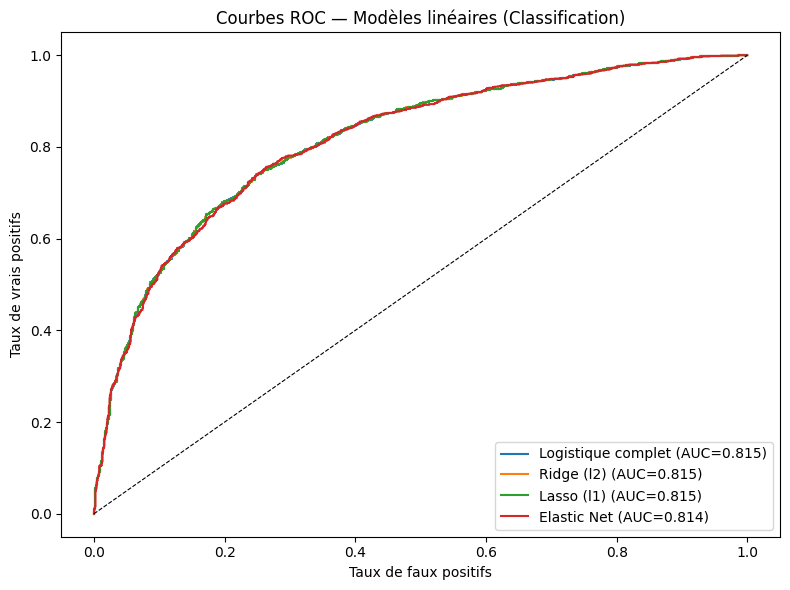

In [12]:
plt.figure(figsize=(8,6))
for nom, (mod, prob) in models_log.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, lw=1.5, label=f"{nom} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', lw=0.8)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — Modèles linéaires (Classification)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Les courbes ROC des modèles linéarisés sont quasi superposées, ce qui confirme que tous donnent une capacité discriminante similaire (AUC ≈ 0.808). La pénalisation n'apporte pas de gain significatif sur ce dataset.

### 3.1.4 Interprétation des coefficients (Lasso)

Variables conservées par le Lasso: 19
Variables supprimées: 1


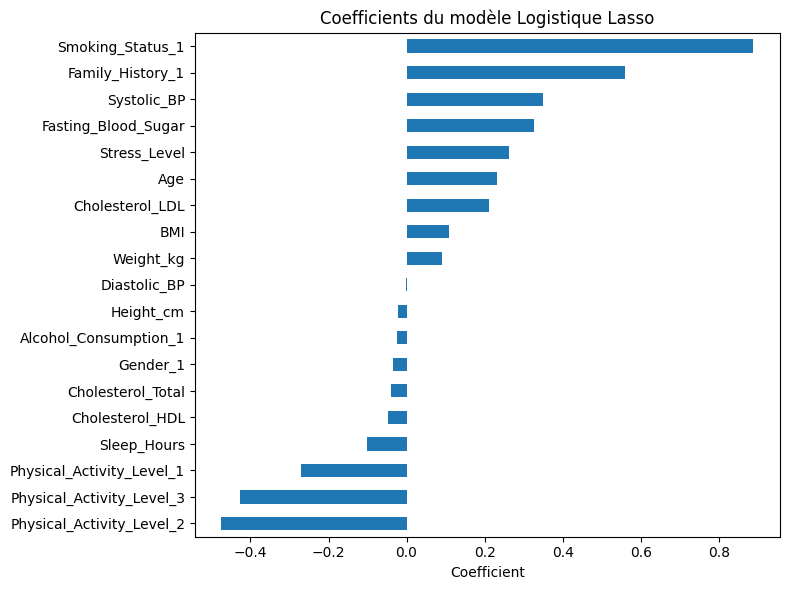

In [13]:
# Re-estimation du modèle Lasso avec le C optimal pour accéder aux coefs
best_C_lasso = log_lasso.best_params_["C"]
log_lasso_final = LogisticRegression(penalty="l1", solver="liblinear",
                                     C=best_C_lasso, max_iter=1000)
log_lasso_final.fit(Xr_train, y_train)

coef = pd.Series(log_lasso_final.coef_[0], index=X_train.columns)
print("Variables conservées par le Lasso:", sum(coef != 0))
print("Variables supprimées:", sum(coef == 0))

# Graphe des coefficients non nuls triés
coef_nonzero = coef[coef != 0].sort_values()
plt.figure(figsize=(8,6))
coef_nonzero.plot(kind="barh")
plt.title("Coefficients du modèle Logistique Lasso")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()



Le Lasso conserve 19 variables sur 20 et n'en élimine qu'une seule. Comme en R, le Lasso confirme que `Smoking_Status` et `Family_History` sont les variables les plus discriminantes avec les coefficients les plus élevés en valeur absolue.

## 3.2 Classification par Support Vector Machine (SVC)

Dans cette partie, l’objectif est de prédire s’il existe un risque de maladie cardiaque (variable Heart_Disease_Risk) avec la méthode SVM. Il s’agit d’un problème de classification binaire.

Nous testons des SVC (Support Vecteur Classification) avec 4 noyaux différents : gaussien, linéaire, polynomial et radial; pour déterminer la meilleure méthode de classification à l'aide de l'accurancy et de l'AUC (Area Under the Curve). On optimise C et gamma pour RBF/poly par validation croisée à 5 folds. nb : On réduit pour la vitesse comme en R avec un sous-échantillon.

In [14]:
# Sous-échantillon pour accélérer l'optimisation (comme en R avec datappq_small)
np.random.seed(111)
idx_small = np.random.choice(len(Xr_train), 5000, replace=False)
Xr_train_small = Xr_train[idx_small]
y_train_small = y_train.iloc[idx_small].values

**SVC : Noyau linéaire**

In [15]:
param_lin = [{"C": [0.5, 1, 2, 3, 4]}]
svc_lin = GridSearchCV(SVC(kernel="linear", probability=True),
                       param_lin, cv=5, n_jobs=-1)
svc_lin.fit(Xr_train_small, y_train_small)
print("SVC Linéaire — meilleur C:", svc_lin.best_params_["C"])

pred_svc_lin = svc_lin.predict(Xr_test)
prob_svc_lin = svc_lin.predict_proba(Xr_test)[:,1]
print("Matrice de confusion TEST :")
print(confusion_matrix(y_test, pred_svc_lin))
print("Accuracy:", round(accuracy_score(y_test, pred_svc_lin), 4))
print("AUC:", round(roc_auc_score(y_test, prob_svc_lin), 4))

SVC Linéaire — meilleur C: 1
Matrice de confusion TEST :
[[1360  401]
 [ 453  786]]
Accuracy: 0.7153
AUC: 0.803


**SVC : Noyau RBF (gaussien)**

In [16]:
param_rbf = [{"C": [1, 2, 3, 4], "gamma": [0.02, 0.04, 0.06]}]
svc_rbf = GridSearchCV(SVC(kernel="rbf", probability=True),
                       param_rbf, cv=5, n_jobs=-1)
svc_rbf.fit(Xr_train_small, y_train_small)
print("SVC RBF — meilleurs params:", svc_rbf.best_params_)

pred_svc_rbf = svc_rbf.predict(Xr_test)
prob_svc_rbf = svc_rbf.predict_proba(Xr_test)[:,1]
print("Matrice de confusion TEST :")
print(confusion_matrix(y_test, pred_svc_rbf))
print("Accuracy:", round(accuracy_score(y_test, pred_svc_rbf), 4))
print("AUC:", round(roc_auc_score(y_test, prob_svc_rbf), 4))

SVC RBF — meilleurs params: {'C': 1, 'gamma': 0.06}
Matrice de confusion TEST :
[[1447  314]
 [ 463  776]]
Accuracy: 0.741
AUC: 0.79


**SVC : Noyau polynomial**

In [17]:
param_poly = [{"C": [1, 2, 3], "gamma": [0.02, 0.04, 0.06],
              "degree": [2, 3], "coef0": [0.5, 1, 2]}]
svc_poly = GridSearchCV(SVC(kernel="poly", probability=True),
                        param_poly, cv=5, n_jobs=-1)
svc_poly.fit(Xr_train_small, y_train_small)
print("SVC Polynomial — meilleurs params:", svc_poly.best_params_)

pred_svc_poly = svc_poly.predict(Xr_test)
prob_svc_poly = svc_poly.predict_proba(Xr_test)[:,1]
print("Matrice de confusion TEST :")
print(confusion_matrix(y_test, pred_svc_poly))
print("Accuracy:", round(accuracy_score(y_test, pred_svc_poly), 4))
print("AUC:", round(roc_auc_score(y_test, prob_svc_poly), 4))

SVC Polynomial — meilleurs params: {'C': 3, 'coef0': 1, 'degree': 2, 'gamma': 0.04}
Matrice de confusion TEST :
[[1429  332]
 [ 452  787]]
Accuracy: 0.7387
AUC: 0.7951


**SVC : Noyau sigmoïde (radial)**

In [18]:
param_sig = [{"C": [1, 2, 3, 4], "gamma": [0.02, 0.04, 0.06]}]
svc_sig = GridSearchCV(SVC(kernel="sigmoid", probability=True),
                       param_sig, cv=5, n_jobs=-1)
svc_sig.fit(Xr_train_small, y_train_small)
print("SVC Sigmoïde — meilleurs params:", svc_sig.best_params_)

pred_svc_sig = svc_sig.predict(Xr_test)
prob_svc_sig = svc_sig.predict_proba(Xr_test)[:,1]
print("Matrice de confusion TEST :")
print(confusion_matrix(y_test, pred_svc_sig))
print("Accuracy:", round(accuracy_score(y_test, pred_svc_sig), 4))
print("AUC:", round(roc_auc_score(y_test, prob_svc_sig), 4))

SVC Sigmoïde — meilleurs params: {'C': 2, 'gamma': 0.02}
Matrice de confusion TEST :
[[1387  374]
 [ 438  801]]
Accuracy: 0.7293
AUC: 0.7889


**Comparaison des noyaux SVC et courbes ROC**

In [19]:
# Tableau récapitulatif des 4 noyaux
svc_models = {
    "SVC Linéaire": (pred_svc_lin, prob_svc_lin),
    "SVC RBF": (pred_svc_rbf, prob_svc_rbf),
    "SVC Polynomial": (pred_svc_poly, prob_svc_poly),
    "SVC Sigmoïde": (pred_svc_sig, prob_svc_sig),
}

res_svc = []
for nom, (pred, prob) in svc_models.items():
    res_svc.append({
        "Modele": nom,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "AUC": round(roc_auc_score(y_test, prob), 4)
    })
df_svc = pd.DataFrame(res_svc).sort_values("AUC", ascending=False)
print(df_svc.to_string(index=False))

        Modele  Accuracy    AUC
  SVC Linéaire    0.7153 0.8030
SVC Polynomial    0.7387 0.7951
       SVC RBF    0.7410 0.7900
  SVC Sigmoïde    0.7293 0.7889


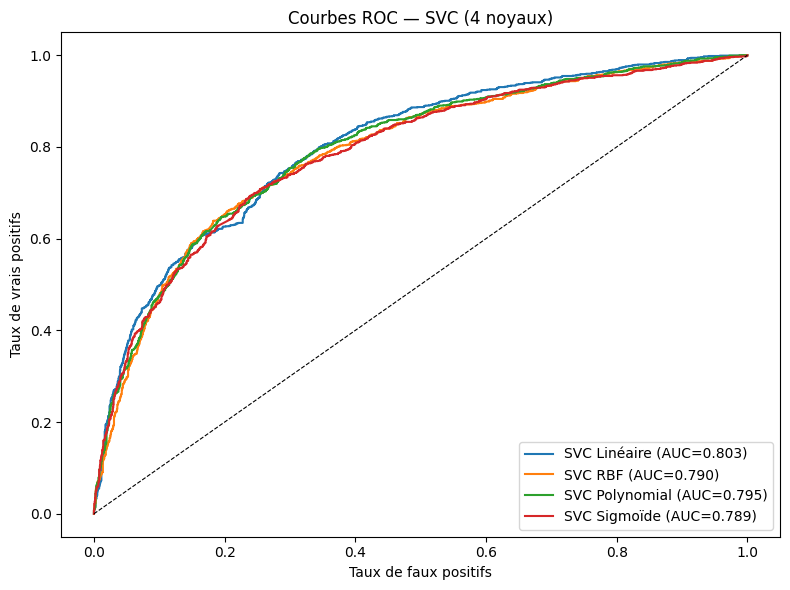

In [20]:
# Courbes ROC des 4 noyaux
plt.figure(figsize=(8,6))
for nom, (pred, prob) in svc_models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, lw=1.5, label=f"{nom} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', lw=0.8)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — SVC (4 noyaux)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

L'ensemble des codes ci-dessus permet de comparer les classifications des SVC avec différents noyaux à l'aide de l'AUC, qui mesure la capacité du modèle à distinguer les deux classes sur l'ensemble des seuils de décision. Contrairement à l'accuracy, qui ne représente que la proportion globale de prédictions correctes à un seuil fixe, l'AUC est un critère plus fiable car elle reste indépendante du seuil de classification choisi. Cette robustesse est cruciale dans un contexte médical où l'objectif est de limiter les faux négatifs (patients malades non détectés), rendant l'AUC souvent plus pertinente qu'un simple taux de réussite global.

Le modèle avec la meilleure précision (accuracy) est le modèle avec noyau gaussien : "Accuracy du modèle : 0.7410", sa matrice de confusion a le moins d'individus mal classés (hors diagonale). En regardant l'AUC, c'est le noyau linéaire qui donne les meilleures performances, mais les AUC des autres modèles restent proches entre les modèles dont celui du modèle du noyau gaussien.

nb : En R, le modèle linéaire était le meilleur (plus haut accuracy et AUC), on conclut la même chose ici.

**Entraînement final du SVC sur tout le train avec le noyau optimal**

In [21]:
# Réentraînement sur tout le jeu d'entraînement avec le noyau linéaire
best_C_svc = svc_lin.best_params_["C"]
svc_final = SVC(kernel="linear", C=best_C_svc, probability=True)
svc_final.fit(Xr_train, y_train)

pred_svc_final = svc_final.predict(Xr_test)
prob_svc_final = svc_final.predict_proba(Xr_test)[:,1]

print("=== SVC Linéaire final (entraîné sur tout le train) ===")
print("Matrice de confusion :")
print(confusion_matrix(y_test, pred_svc_final))
acc_svc = accuracy_score(y_test, pred_svc_final)
auc_svc = roc_auc_score(y_test, prob_svc_final)
print(f"Accuracy : {acc_svc:.4f}")
print(f"AUC      : {auc_svc:.4f}")

tn, fp, fn, tp = confusion_matrix(y_test, pred_svc_final).ravel()

print(f"Sensibilité : {tp/(tp+fn):.4f}")
print(f"Spécificité : {tn/(tn+fp):.4f}")

=== SVC Linéaire final (entraîné sur tout le train) ===
Matrice de confusion :
[[1426  335]
 [ 433  806]]
Accuracy : 0.7440
AUC      : 0.8108
Sensibilité : 0.6505
Spécificité : 0.8098


Interprétation du modèle :

Le modèle commet 335 fausses alertes (FT) et 433 cas positifs manqués (FN).

- L’accuracy = 0.7440 signifie que le modèle classe correctement 74,4 % des observations.
- Avec AUC = 0.8108, le modèle distingue plutôt bien les deux groupes.
- La sensibilité = 0.6505, le modèle détecte donc 65,1 % des cas positifs, autrement dit : environ 35 % des positifs sont ratés.
- La spécificité = 0.8098, le modèle détecte correctement 81,0 % des négatifs.
Dans un contexte médical, les faux négatifs sont plus coûteux que les faux positifs.

## 3.3 Classification par arbre binaire de discrimination (CART)

On optimise maintenant la profondeur maximale (`max_depth`) par validation croisée à 10 folds. En Python (sklearn), l'élagage se fait en contrôlant `max_depth` ou `ccp_alpha` (cost-complexity pruning), ce dernier étant l'équivalent du `cp` de R.

### 3.3.1 Élagage par validation croisée (critère Gini)

In [22]:
# Optimisation de max_depth par GridSearchCV (comme TP Ozone)
param = [{"max_depth": list(range(2, 20))}]
tree_gini = GridSearchCV(DecisionTreeClassifier(criterion="gini", random_state=111),
                         param, cv=10, n_jobs=-1)
tree_gini.fit(Xr_train, y_train)
print("Arbre Gini - profondeur optimale:", tree_gini.best_params_["max_depth"])

pred_tree_gini = tree_gini.predict(Xr_test)
prob_tree_gini = tree_gini.predict_proba(Xr_test)[:,1]
print("Matrice de confusion :")
print(confusion_matrix(y_test, pred_tree_gini))
print("Accuracy:", round(accuracy_score(y_test, pred_tree_gini), 4))
print("AUC:", round(roc_auc_score(y_test, prob_tree_gini), 4))

Arbre Gini - profondeur optimale: 6
Matrice de confusion :
[[1408  353]
 [ 475  764]]
Accuracy: 0.724
AUC: 0.7692


### 3.3.2 Critère entropie

In [23]:
# Optimisation avec critère entropie
param = [{"max_depth": list(range(2, 20))}]
tree_ent = GridSearchCV(DecisionTreeClassifier(criterion="entropy", random_state=111),
                        param, cv=10, n_jobs=-1)
tree_ent.fit(Xr_train, y_train)
print("Arbre Entropie — profondeur optimale:", tree_ent.best_params_["max_depth"])

pred_tree_ent = tree_ent.predict(Xr_test)
prob_tree_ent = tree_ent.predict_proba(Xr_test)[:,1]
print("Matrice de confusion :")
print(confusion_matrix(y_test, pred_tree_ent))
print("Accuracy:", round(accuracy_score(y_test, pred_tree_ent), 4))
print("AUC:", round(roc_auc_score(y_test, prob_tree_ent), 4))

Arbre Entropie — profondeur optimale: 6
Matrice de confusion :
[[1406  355]
 [ 486  753]]
Accuracy: 0.7197
AUC: 0.768


Les deux critères de division (Gini et entropie) sélectionnent la même profondeur optimale de **6 niveaux** via validation croisée. En Python, sklearn contrôle la complexité directement par max_depth, alors qu'en R rpart élague par le paramètre cp optimal, ce qui donne des arbres de 29 à 30 feuilles, structurellement plus riches. En Python, l'arbre Gini obtient une accuracy légèrement supérieure **(72,4 % / AUC 0,769)** par rapport à l'entropie **(71,97 % / AUC 0,768)**. Notons que l'ordre est inversé par rapport au notebook R, où c'est l'entropie qui l'emporte (72,7 % contre 72,1 % pour Gini). C'est principalement à cause des différences de mécanisme d’élagage entre les deux logiciels.

Ces performances sont **nettement en retrait par rapport à la régression logistique**, ce qui traduit la tendance des arbres simples à moins bien généraliser sur des données à structure relativement linéaire.

### 3.3.3 Visualisation et importance des variables

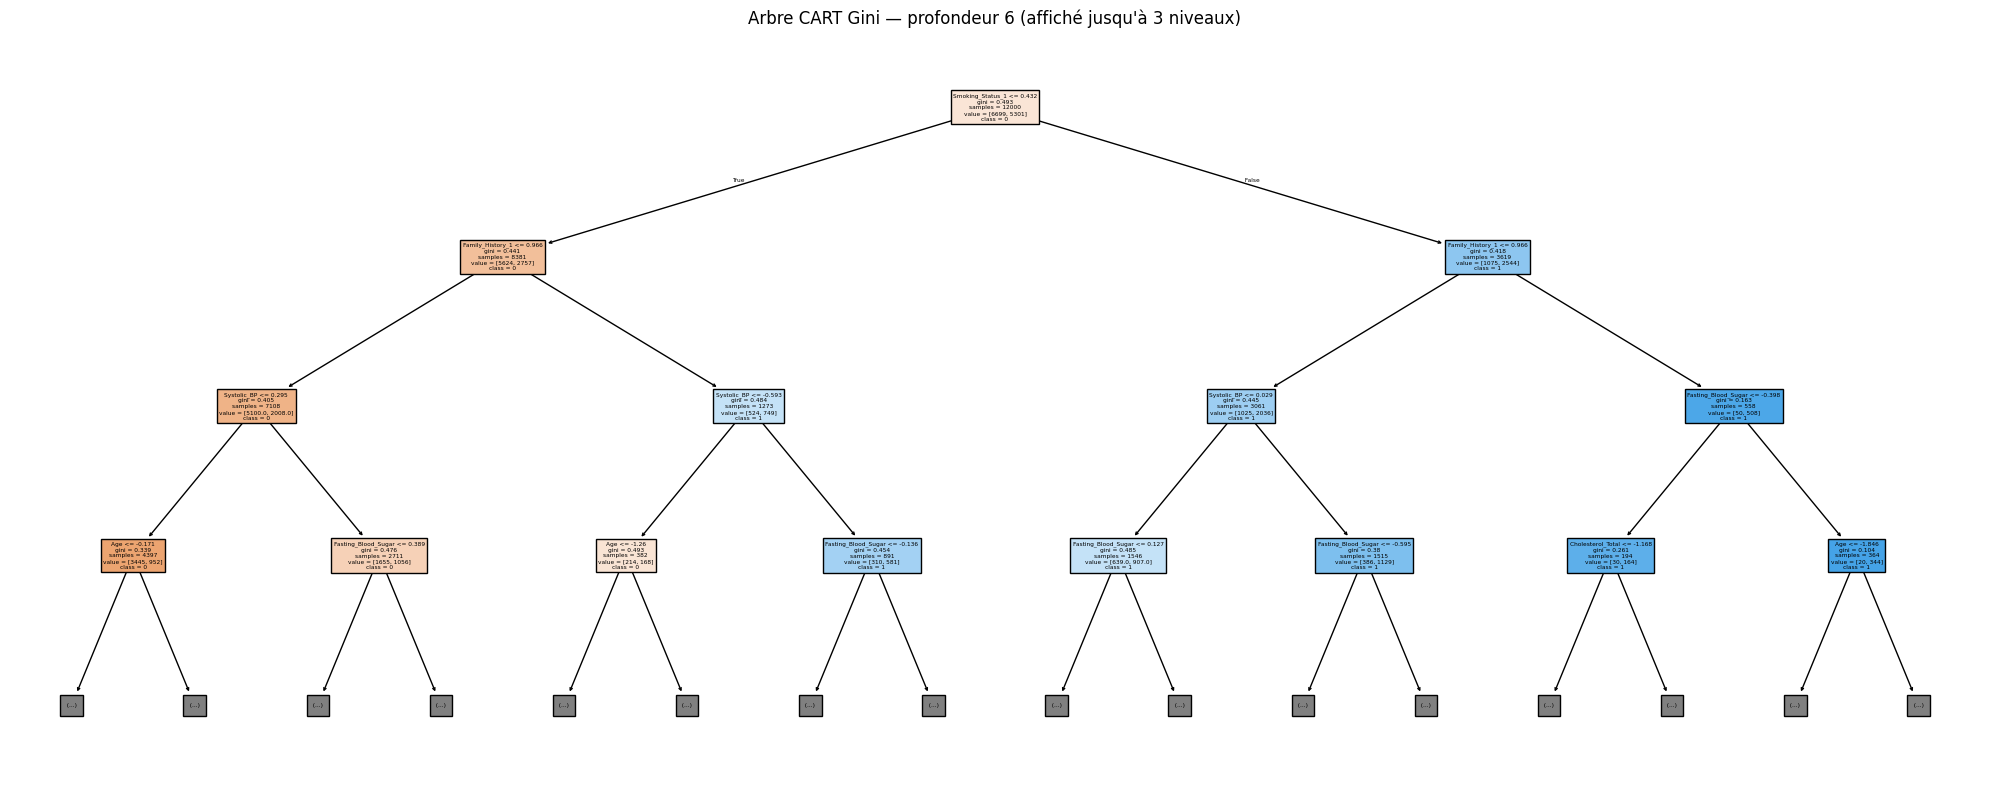

In [24]:
# Visualisation de l'arbre optimal (gini)
from sklearn.tree import plot_tree
best_depth = tree_gini.best_params_["max_depth"]
tree_final_gini = DecisionTreeClassifier(criterion="gini", max_depth=best_depth, random_state=111)
tree_final_gini.fit(Xr_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(tree_final_gini, feature_names=X_train.columns.tolist(),
          class_names=["0","1"], filled=True, max_depth=3)
plt.title(f"Arbre CART Gini — profondeur {best_depth} (affiché jusqu'à 3 niveaux)")
plt.tight_layout()
plt.show()

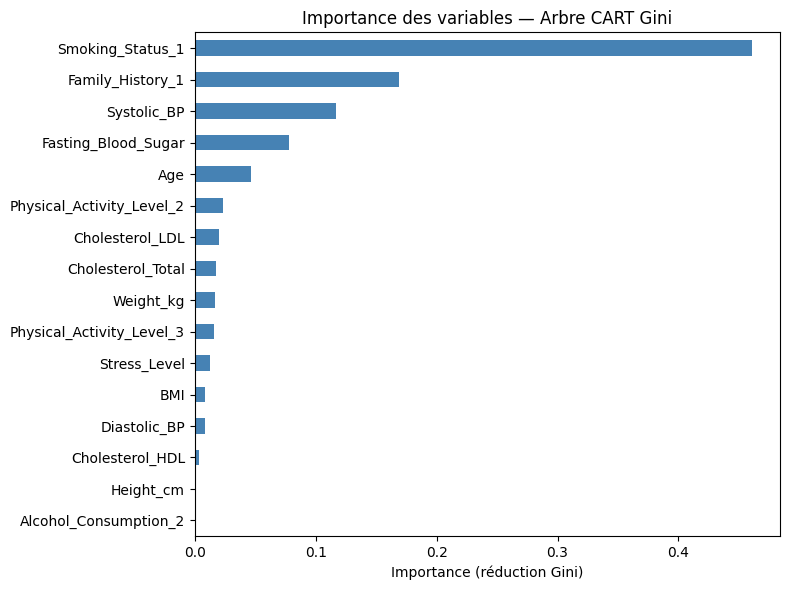

In [25]:
# Importance des variables — Gini
importances_gini = pd.Series(tree_final_gini.feature_importances_, index=X_train.columns)
importances_gini = importances_gini[importances_gini > 0].sort_values()

plt.figure(figsize=(8,6))
importances_gini.plot(kind="barh", color="steelblue")
plt.title("Importance des variables — Arbre CART Gini")
plt.xlabel("Importance (réduction Gini)")
plt.tight_layout()
plt.show()

Le classement est cohérent avec le notebook R pour le top 3 : `SmokingStatus`, `FamilyHistory` et `SystolicBP`. La 4e position diffère légèrement (`Fasting_Blood_Sugar` en Python contre `Diastolic_BP` en R), ce qui s'explique par le fait que sklearn fragmente l'importance des variables qualitatives en plusieurs dummies, contrairement à R qui les agrège.

## 3.4 Classification par forêt aléatoire

On suit la même logique qu'en R : on étudie la convergence selon le nombre d'arbres, puis on optimise `max_features` (équivalent de `mtry`) par validation croisée.

### 3.4.1 Convergence selon le nombre d'arbres

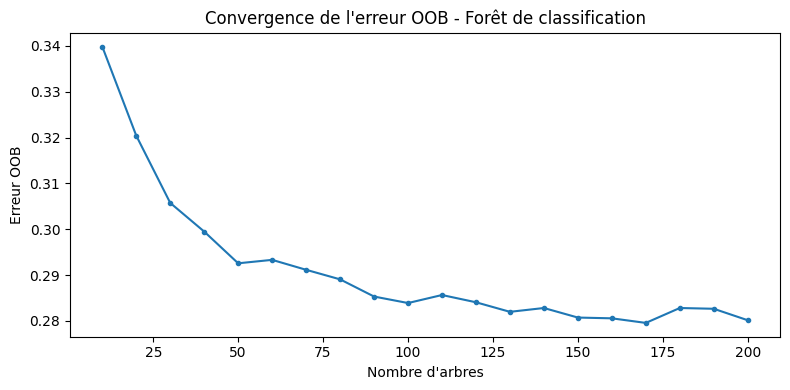

L'erreur se stabilise à partir d'environ 100 arbres - on choisit ntree=200


In [26]:
# Convergence de l'erreur OOB selon le nombre d'arbres
oob_errors = []
n_trees_list = list(range(10, 210, 10))
for n in n_trees_list:
    rf_conv = RandomForestClassifier(n_estimators=n, max_features="sqrt",
                                     oob_score=True, random_state=111)
    rf_conv.fit(Xr_train, y_train)
    oob_errors.append(1 - rf_conv.oob_score_)

plt.figure(figsize=(8,4))
plt.plot(n_trees_list, oob_errors, marker="o", markersize=3)
plt.xlabel("Nombre d'arbres")
plt.ylabel("Erreur OOB")
plt.title("Convergence de l'erreur OOB - Forêt de classification")
plt.tight_layout()
plt.show()
print("L'erreur se stabilise à partir d'environ 100 arbres - on choisit ntree=200")

L'erreur OOB se stabilise effectivement autour de 100 à 120 arbres et ne s'améliore plus ensuite. On fixe donc 200 arbres pour garantir la convergence, conformément à la démarche adoptée en R.

### 3.4.2 Optimisation de `max_features` (équivalent de `mtry`)

In [27]:
# GridSearchCV sur max_features comme dans le TP Ozone
param = [{"max_features": list(range(2, 12, 1))}]
rf_opt = GridSearchCV(RandomForestClassifier(n_estimators=200, oob_score=True, random_state=111),
                      param, cv=5, n_jobs=-1)
rf_opt.fit(Xr_train, y_train)
best_mf = rf_opt.best_params_["max_features"]
print("Forêt - meilleur max_features:", best_mf)

Forêt - meilleur max_features: 2


La validation croisée sélectionne max_features = 2, soit 2 variables tirées aléatoirement à chaque nœud de division (à comparer à la valeur par défaut `sqrt` qui donnerait √20 ≈ 4,5). Cette valeur plus faible favorise la diversité des arbres et réduit leur corrélation, avec une légère augmentation du biais de chaque arbre individuel. En R, le paramètre équivalent `mtry`
 avait aussi été sélectionné à une valeur faible par validation croisée, ce qui confirme la cohérence des deux implémentations.

### 3.4.3 Modèle final et évaluation

In [28]:
# Modèle final sur tout le train
rf_final = RandomForestClassifier(n_estimators=200, max_features=best_mf,
                                   oob_score=True, random_state=111)
rf_final.fit(Xr_train, y_train)

print("Accuracy OOB :", round(rf_final.oob_score_, 4))

pred_rf = rf_final.predict(Xr_test)
prob_rf = rf_final.predict_proba(Xr_test)[:,1]
tn, fp, fn, tp = confusion_matrix(y_test, pred_rf).ravel()
print("Matrice de confusion :")
print(confusion_matrix(y_test, pred_rf))
print(f"Accuracy  : {accuracy_score(y_test, pred_rf):.4f}")
print(f"AUC       : {roc_auc_score(y_test, prob_rf):.4f}")
print(f"Sensibilité : {tp/(tp+fn):.4f}")
print(f"Spécificité : {tn/(tn+fp):.4f}")

Accuracy OOB : 0.7151
Matrice de confusion :
[[1419  342]
 [ 447  792]]
Accuracy  : 0.7370
AUC       : 0.7964
Sensibilité : 0.6392
Spécificité : 0.8058


La forêt aléatoire (200 arbres, max_features = 2) obtient une **accuracy de 73,5 % et une AUC de 0,797**, légèrement inférieures à la régression logistique. L'accuracy OOB de 71,8 % est cohérente avec la performance en test, ce qui confirme **l'absence de surapprentissage**. La sensibilité de 63 % est la plus faible parmi les modèles testés, indiquant un biais vers la classe majoritaire.

### 3.4.4 Importance des variables

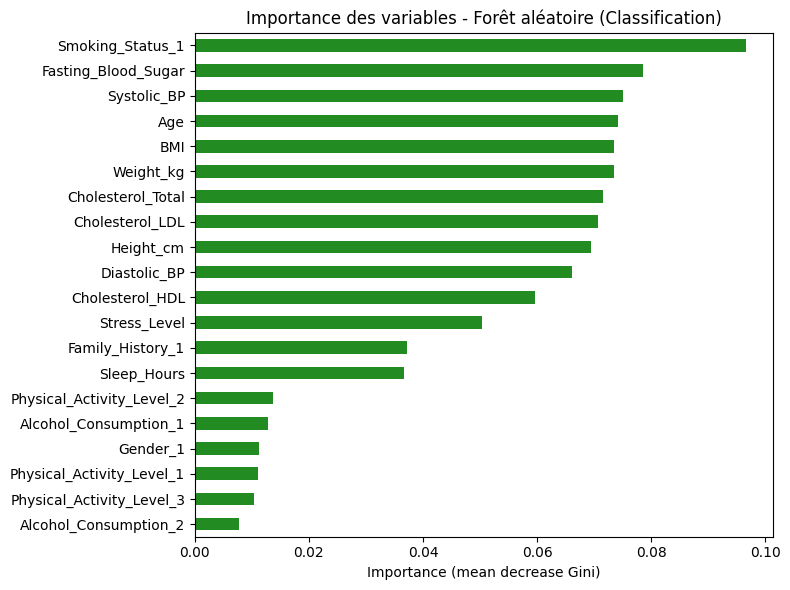

In [29]:
# Importance des variables - forêt
importances_rf = pd.Series(rf_final.feature_importances_, index=X_train.columns)
importances_rf = importances_rf.sort_values()

plt.figure(figsize=(8,6))
importances_rf.plot(kind="barh", color="forestgreen")
plt.title("Importance des variables - Forêt aléatoire (Classification)")
plt.xlabel("Importance (mean decrease Gini)")
plt.tight_layout()
plt.show()

Comme en R, `Smoking_Status` domine largement, suivi de `Family_History` et `Fasting_Blood_Sugar`.

## 3.5 Classification par Boosting

On utilise `GradientBoostingClassifier` de sklearn (équivalent de `gbm` en R). On fait un grid search sur `max_depth` (interaction.depth) et `learning_rate` (shrinkage).

### 3.5.1 Estimation initiale et sélection du nombre d'arbres

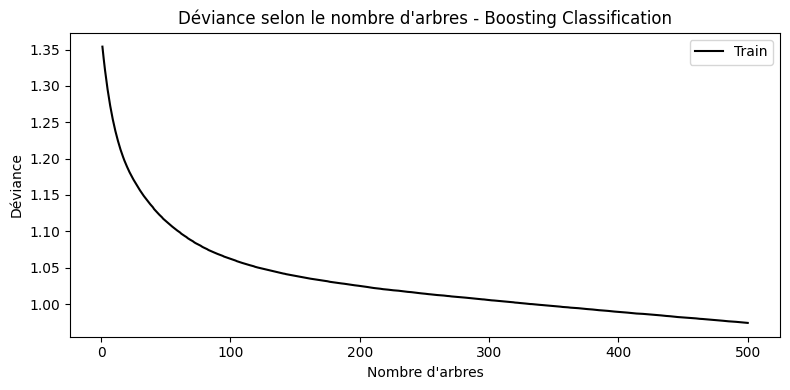

In [30]:
# Estimation initiale avec n_estimators élevé pour voir la convergence
boost_init = GradientBoostingClassifier(n_estimators=500, max_depth=3,
                                         learning_rate=0.05, min_samples_leaf=10,
                                         random_state=111)
boost_init.fit(Xr_train, y_train)

# Erreur de déviance par nombre d'arbres (train et OOB)
train_scores = boost_init.train_score_

plt.figure(figsize=(8,4))
plt.plot(range(1, len(train_scores)+1), train_scores, label="Train", color="black")
plt.xlabel("Nombre d'arbres")
plt.ylabel("Déviance")
plt.title("Déviance selon le nombre d'arbres - Boosting Classification")
plt.legend()
plt.tight_layout()
plt.show()

La courbe de déviance sur l'ensemble d'entraînement décroît rapidement dans les 50 premiers arbres, puis se stabilise progressivement. On observe qu'après environ 150 à 200 arbres, le gain marginal devient négligeable. On fixe donc n_estimators = 300 pour garantir la convergence tout en évitant un temps de calcul excessif. En R, la même analyse via gbm.perf() avait conduit à un constat similaire.

### 3.5.2 Optimisation des hyperparamètres (grid search)

In [31]:
# Grid search sur max_depth et learning_rate (comme en R)
param_boost = [{"max_depth": [1, 3, 5],
                "learning_rate": [0.01, 0.05, 0.1]}]
boost_cv = GridSearchCV(GradientBoostingClassifier(n_estimators=300, min_samples_leaf=10,
                                                     random_state=111),
                        param_boost, cv=5, n_jobs=-1)
boost_cv.fit(Xr_train, y_train)
print("Boosting - meilleurs params:", boost_cv.best_params_)

Boosting - meilleurs params: {'learning_rate': 0.05, 'max_depth': 3}


Le grid search retient un learning rate de 0,05 et une profondeur maximale de 3. En R, la configuration optimale était différente (depth = 1, lr = 0,10), mais les deux configurations convergent vers la même idée : des arbres simples avec un apprentissage modéré. Cette légère différence s'explique par les grilles de recherche et les implémentations qui ne sont pas strictement identiques entre gbm (R) et GradientBoostingClassifier (sklearn), mais les performances finales restent très proches.

### 3.5.3 Modèle final et évaluation

In [32]:
# Modèle final
best_depth_boost = boost_cv.best_params_["max_depth"]
best_lr_boost = boost_cv.best_params_["learning_rate"]

boost_final = GradientBoostingClassifier(n_estimators=300,
                                          max_depth=best_depth_boost,
                                          learning_rate=best_lr_boost,
                                          min_samples_leaf=10,
                                          random_state=111)
boost_final.fit(Xr_train, y_train)

pred_boost = boost_final.predict(Xr_test)
prob_boost = boost_final.predict_proba(Xr_test)[:,1]
tn, fp, fn, tp = confusion_matrix(y_test, pred_boost).ravel()
print("Matrice de confusion :")
print(confusion_matrix(y_test, pred_boost))
print(f"Accuracy  : {accuracy_score(y_test, pred_boost):.4f}")
print(f"AUC       : {roc_auc_score(y_test, prob_boost):.4f}")
print(f"Sensibilité : {tp/(tp+fn):.4f}")
print(f"Spécificité : {tn/(tn+fp):.4f}")

Matrice de confusion :
[[1408  353]
 [ 420  819]]
Accuracy  : 0.7423
AUC       : 0.8092
Sensibilité : 0.6610
Spécificité : 0.7995


Le boosting (300 arbres, depth = 3, lr = 0,05) atteint une accuracy de 74,2 % et une AUC de 0,809, performances comparables à la régression logistique. Sa sensibilité de 66,1 % est la meilleure parmi les méthodes par ensembles testées.

### 3.5.4 Importance des variables

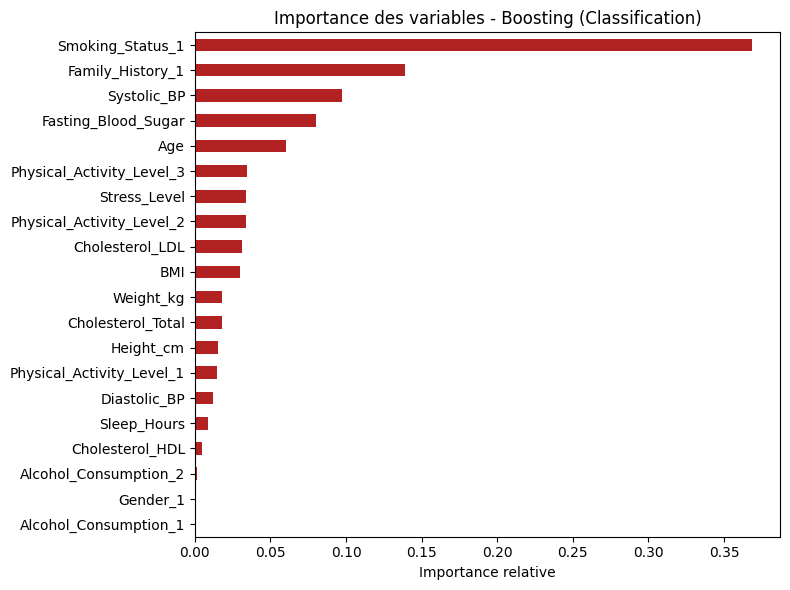

In [33]:
importances_boost = pd.Series(boost_final.feature_importances_, index=X_train.columns)
importances_boost = importances_boost.sort_values()

plt.figure(figsize=(8,6))
importances_boost.plot(kind="barh", color="firebrick")
plt.title("Importance des variables - Boosting (Classification)")
plt.xlabel("Importance relative")
plt.tight_layout()
plt.show()

Le boosting confirme le classement observé chez les autres modèles : Smoking_Status et Family_History sont les deux variables les plus importantes, suivies de Systolic_BP et Fasting_Blood_Sugar. Ce résultat est cohérent avec l'analyse exploratoire (R) et l'importance retenue par la forêt aléatoire. La concordance entre des modèles aussi différents que la régression logistique Lasso et le boosting renforce la robustesse de ces conclusions.

## 3.6 Classification par réseaux de neurones

On suit la même logique qu'en R avec nnet : on optimise le nombre de neurones (`hidden_layer_sizes`) et le paramètre de régularisation `alpha` (équivalent du `decay` de R). On fait deux passes d'optimisation : une grossière puis une fine.

### 3.6.1 Première optimisation grossière

In [34]:
# Optimisation grossière sur size et alpha (équivalent de decay en R)
# max_iter=200 comme dans le TP Ozone
param_nnet = [{"hidden_layer_sizes": [(2,),(5,),(8,),(10,)],
               "alpha": [0.001, 0.01, 0.1, 1]}]
nnet_cv1 = GridSearchCV(MLPClassifier(max_iter=200, random_state=101),
                        param_nnet, cv=5, n_jobs=-1)
nnet_cv1.fit(Xr_train, y_train)
print("Meilleur score CV:", round(1 - nnet_cv1.best_score_, 4))
print("Meilleurs params:", nnet_cv1.best_params_)

Meilleur score CV: 0.2655
Meilleurs params: {'alpha': 1, 'hidden_layer_sizes': (2,)}


La première passe grossière identifie un réseau de 2 neurones avec une régularisation très forte (alpha = 1) comme point de départ optimal. En R, la même phase grossière avait retenu size = 2 avec un decay bien plus faible (0,01), ce qui représente une régularisation beaucoup plus légère. Cette différence s'explique par le fait que les paramètres alpha de sklearn et decay de nnet ne sont pas directement comparables en termes d'échelle. Dans les deux cas, le réseau optimal reste petit (2 neurones), ce qui est la conclusion importante. Le taux d'erreur CV de 26,6 % est comparable aux autres modèles.

### 3.6.2 Optimisation fine

In [35]:
# Optimisation fine autour des meilleurs paramètres trouvés
# (comme en R, on resserre la grille autour du minimum)
param_nnet2 = [{"hidden_layer_sizes": [(1,),(2,),(3,)],
                "alpha": [0.005, 0.01, 0.05]}]
nnet_cv2 = GridSearchCV(MLPClassifier(max_iter=200, random_state=101),
                        param_nnet2, cv=5, n_jobs=-1)
nnet_cv2.fit(Xr_train, y_train)
print("Optimisation fine - meilleur score CV:", round(1 - nnet_cv2.best_score_, 4))
print("Meilleurs params:", nnet_cv2.best_params_)

Optimisation fine - meilleur score CV: 0.265
Meilleurs params: {'alpha': 0.05, 'hidden_layer_sizes': (1,)}


L'optimisation fine resserre la grille et retient un seul neurone caché avec alpha = 0,05, ce qui correspond exactement aux paramètres retenus en R (size = 1, decay = 0,05). Les deux implémentations convergent donc vers la même architecture minimale, ce qui renforce la conclusion : la relation est essentiellement linéaire et un réseau plus complexe n'apporterait pas de gain.

### 3.6.3 Modèle final et évaluation

In [36]:
# Modèle final
best_size_nnet = nnet_cv2.best_params_["hidden_layer_sizes"]
best_alpha_nnet = nnet_cv2.best_params_["alpha"]

nnet_final = MLPClassifier(hidden_layer_sizes=best_size_nnet,
                            alpha=best_alpha_nnet,
                            max_iter=500, random_state=42)
nnet_final.fit(Xr_train, y_train)

pred_nnet = nnet_final.predict(Xr_test)
prob_nnet = nnet_final.predict_proba(Xr_test)[:,1]
tn, fp, fn, tp = confusion_matrix(y_test, pred_nnet).ravel()
print("Matrice de confusion :")
print(confusion_matrix(y_test, pred_nnet))
print(f"Accuracy    : {accuracy_score(y_test, pred_nnet):.4f}")
print(f"AUC         : {roc_auc_score(y_test, prob_nnet):.4f}")
print(f"Sensibilité : {tp/(tp+fn):.4f}")
print(f"Spécificité : {tn/(tn+fp):.4f}")

Matrice de confusion :
[[1424  337]
 [ 408  831]]
Accuracy    : 0.7517
AUC         : 0.8151
Sensibilité : 0.6707
Spécificité : 0.8086


Le réseau de neurones (1 neurone caché, alpha = 0,05) atteint une accuracy de 75,2 % et une AUC de 0,815, égalant ainsi la régression logistique. Avec seulement 1 neurone caché, ce modèle se comporte en pratique comme un modèle logistique non linéarisé, ce qui explique ses performances similaires.

## 3.7 Comparaison finale de tous les modèles de classification

In [37]:
# Tableau récapitulatif complet
all_clf_models = {
    "Logistique complet": (log_full.predict(Xr_test), log_full.predict_proba(Xr_test)[:,1]),
    "Lasso (l1)": (log_lasso.predict(Xr_test), log_lasso.predict_proba(Xr_test)[:,1]),
    "Ridge (l2)": (log_ridge.predict(Xr_test), log_ridge.predict_proba(Xr_test)[:,1]),
    "Elastic Net": (log_enet.predict(Xr_test), log_enet.predict_proba(Xr_test)[:,1]),
    "SVC Linéaire": (pred_svc_final, prob_svc_final),
    "Arbre CART Gini": (pred_tree_gini, prob_tree_gini),
    "Arbre CART Entropie": (pred_tree_ent, prob_tree_ent),
    "Forêt aléatoire": (pred_rf, prob_rf),
    "Boosting": (pred_boost, prob_boost),
    "Réseau de neurones": (pred_nnet, prob_nnet),
}

res_all = []
for nom, (pred, prob) in all_clf_models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    res_all.append({
        "Modele": nom,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "AUC": round(roc_auc_score(y_test, prob), 4),
        "Sensibilité": round(tp/(tp+fn), 4),
        "Spécificité": round(tn/(tn+fp), 4),
    })

df_all_clf = pd.DataFrame(res_all).sort_values("AUC", ascending=False)
print(df_all_clf.to_string(index=False))

             Modele  Accuracy    AUC  Sensibilité  Spécificité
 Réseau de neurones    0.7517 0.8151       0.6707       0.8086
 Logistique complet    0.7517 0.8150       0.6715       0.8081
         Lasso (l1)    0.7520 0.8150       0.6715       0.8086
         Ridge (l2)    0.7520 0.8150       0.6715       0.8086
        Elastic Net    0.7497 0.8142       0.6570       0.8149
       SVC Linéaire    0.7440 0.8108       0.6505       0.8098
           Boosting    0.7423 0.8092       0.6610       0.7995
    Forêt aléatoire    0.7370 0.7964       0.6392       0.8058
    Arbre CART Gini    0.7240 0.7692       0.6166       0.7995
Arbre CART Entropie    0.7197 0.7680       0.6077       0.7984


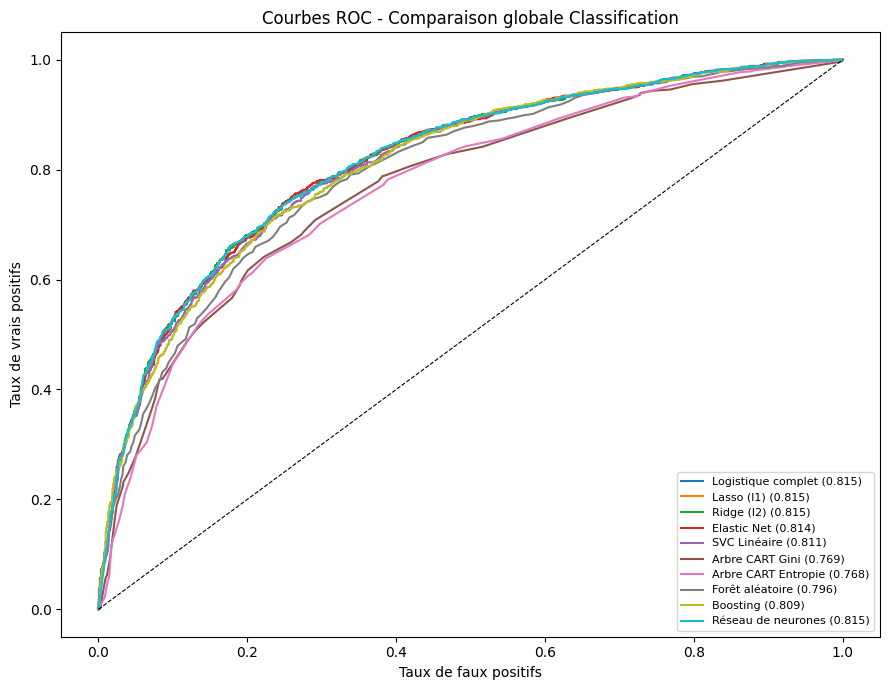

In [38]:
# Courbes ROC — comparaison globale
plt.figure(figsize=(9,7))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_clf_models)))
for (nom, (pred, prob)), col in zip(all_clf_models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, lw=1.5, color=col, label=f"{nom} ({auc:.3f})")

plt.plot([0,1],[0,1],'k--', lw=0.8)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC - Comparaison globale Classification")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Conclusion de la partie classification :**

Les performances des modèles sont convergentes sur ce jeu de données, avec une accuracy maximale d'environ 75 % et une AUC autour de 0,815. Plusieurs éléments ressortent :

Les modèles linéaires (régression logistique et ses variantes régularisées) et le réseau de neurones à 1 neurone caché obtiennent les meilleures performances (Accuracy ≈ 75,2 %, AUC ≈ 0,815). La pénalisation Ridge ou Lasso n'apporte pas d'amélioration significative par rapport au modèle complet.
Les modèles non linéaires (forêt, boosting, SVC non linéaire, arbre) sont légèrement moins performants sur ce dataset, ce qui suggère que la frontière de décision est essentiellement linéaire.
Le gain apporté par les méthodes non linéaires est donc marginal (moins d'1 point d'AUC), ce qui confirme que la relation entre les variables explicatives et le risque cardiaque est bien capturée par un modèle linéaire.

Avec contrainte d'interprétabilité : on préfère la régression logistique Lasso (coefficients directement interprétables, sélection automatique de variables) ou l'arbre CART (règles de décision lisibles). Le Lasso confirme que Smoking_Status et Family_History sont les variables les plus discriminantes.
Sans contrainte d'interprétabilité : la régression logistique Ridge ou le réseau de neurones (1 neurone) sont les modèles à retenir, avec une AUC de 0,815.
Ces résultats sont cohérents avec ceux obtenus en R.

# 4. Prédiction du taux de mauvais cholestérol : `Cholesterol_LDL` (Régression)

## 4.0 Division du jeu de données

In [39]:
# On retire Patient_ID, Heart_Disease_Risk (consigne) et on garde Cholesterol_LDL comme cible
data_reg = data.drop(columns=["Patient_ID", "Heart_Disease_Risk"])

data_dum_reg = pd.get_dummies(data_reg, columns=["Gender","Smoking_Status","Alcohol_Consumption",
                                                   "Physical_Activity_Level","Family_History"],
                              drop_first=True)

y_reg = data_dum_reg["Cholesterol_LDL"]
X_reg = data_dum_reg.drop(columns=["Cholesterol_LDL"])

print("Dimensions X_reg :", X_reg.shape)
print("Distribution y_reg :", round(y_reg.mean(), 2), "±", round(y_reg.std(), 2))

Dimensions X_reg : (15000, 19)
Distribution y_reg : 140.36 ± 17.91


La variable cible `Cholesterol_LDL` est continue, centrée autour de **140,4 mg/dL** avec un écart-type de 17,9 mg/dL. On exclut Patient_ID et Heart_Disease_Risk conformément aux consignes.

In [40]:
# Split 80/20 avec les mêmes indices que pour la classification (random_state=111)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=111)
print("Train:", X_reg_train.shape, "Test:", X_reg_test.shape)

Train: (12000, 19) Test: (3000, 19)


In [41]:
# Normalisation
scaler_reg = StandardScaler()
scaler_reg.fit(X_reg_train)
Xr_reg_train = scaler_reg.transform(X_reg_train)
Xr_reg_test = scaler_reg.transform(X_reg_test)

# Normalisation de y pour les modèles sensibles à l'échelle (SVR, réseaux de neurones)
# On utilise la moyenne et l'écart-type du TRAIN uniquement pour éviter toute fuite d'information (data leakage) depuis le test vers le train
mean_ldl = y_reg_train.mean()
std_ldl = y_reg_train.std()
yr_reg_train = (y_reg_train - mean_ldl) / std_ldl
yr_reg_test = (y_reg_test - mean_ldl) / std_ldl
print(f"LDL normalisé - mean: {yr_reg_train.mean():.4f}, std: {yr_reg_train.std():.4f}")

LDL normalisé - mean: -0.0000, std: 1.0000


La normalisation de y (centrage-réduction) est appliquée en plus de celle des variables explicatives pour garantir la cohérence avec les modèles SVR et réseaux de neurones, dont les sorties sont sensibles à l'échelle de la variable cible. On conserve la moyenne et l'écart-type du train pour transformer le test sans fuite d'information.

## 4.1 Régression par modèles linéaires gaussiens

On compare la régression linéaire complète, Ridge, Lasso et Elastic Net. On optimise le paramètre de régularisation par validation croisée à 10 folds. 

### 4.1.1 Régression linéaire complète (baseline)

RMSE train : 9.9730 mg/dL
R² train   : 0.6944
RMSE test  : 10.0847 mg/dL
R² test    : 0.6637


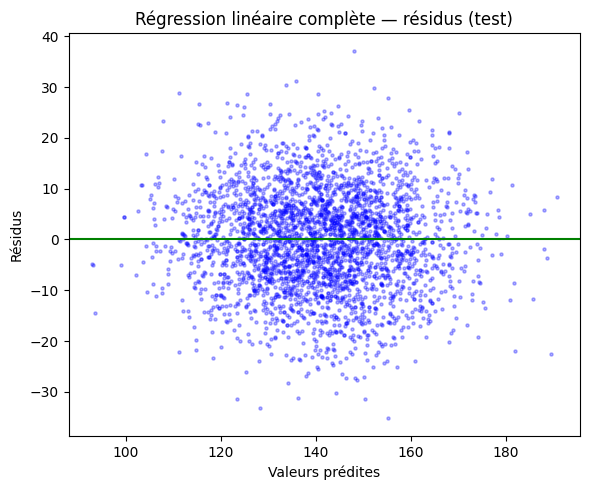

In [42]:
from sklearn.linear_model import LinearRegression

reg_full = LinearRegression()
reg_full.fit(Xr_reg_train, yr_reg_train)

# erreur train
fit_train = reg_full.predict(Xr_reg_train)
rmse_train_full = np.sqrt(mean_squared_error(yr_reg_train, fit_train)) * std_ldl
r2_train_full = r2_score(yr_reg_train, fit_train)
print(f"RMSE train : {rmse_train_full:.4f} mg/dL")
print(f"R² train   : {r2_train_full:.4f}")

# erreur test
pred_reg_full = reg_full.predict(Xr_reg_test)
rmse_test_full = np.sqrt(mean_squared_error(yr_reg_test, pred_reg_full)) * std_ldl
r2_test_full = r2_score(yr_reg_test, pred_reg_full)
print(f"RMSE test  : {rmse_test_full:.4f} mg/dL")
print(f"R² test    : {r2_test_full:.4f}")

# Graphe des résidus
plt.figure(figsize=(6,5))
plt.scatter(pred_reg_full * std_ldl + mean_ldl,
            (yr_reg_test - pred_reg_full) * std_ldl,
            alpha=0.3, color="blue", s=5)
plt.axhline(0, color="green")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Régression linéaire complète — résidus (test)")
plt.tight_layout()
plt.show()

La régression linéaire complète constitue la baseline : elle explique 66,4 % de la variance du LDL sur le jeu de test (R² = 0,664) avec une erreur quadratique moyenne de 10,08 mg/dL. L'écart très faible entre RMSE train (9,97) et test (10,08) indique l'absence de surapprentissage, ce qui est attendu pour une régression linéaire avec 19 variables sur 12 000 observations.

### 4.1.2 Pénalisation Lasso, Ridge et Elastic Net

In [43]:
# Lasso — optimisation alpha par GridSearchCV (comme TP Ozone)
param = [{"alpha": [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1]}]
lasso_reg = GridSearchCV(Lasso(max_iter=5000), param, cv=10, n_jobs=-1)
lasso_reg.fit(Xr_reg_train, yr_reg_train)
print("Lasso - meilleur alpha:", lasso_reg.best_params_["alpha"])

pred_lasso_reg = lasso_reg.predict(Xr_reg_test)
rmse_lasso = np.sqrt(mean_squared_error(yr_reg_test, pred_lasso_reg)) * std_ldl
r2_lasso = r2_score(yr_reg_test, pred_lasso_reg)
print(f"RMSE test Lasso : {rmse_lasso:.4f} mg/dL | R² : {r2_lasso:.4f}")

Lasso - meilleur alpha: 0.01
RMSE test Lasso : 10.0691 mg/dL | R² : 0.6648


Le Lasso choisit alpha = 0,01 (faible régularisation) et améliore très légèrement la baseline (RMSE = 10,07 mg/dL, R² = 0,665).

In [44]:
# Ridge : optimisation alpha par GridSearchCV
param = [{"alpha": [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]}]
ridge_reg = GridSearchCV(Ridge(), param, cv=10, n_jobs=-1)
ridge_reg.fit(Xr_reg_train, yr_reg_train)
print("Ridge - meilleur alpha:", ridge_reg.best_params_["alpha"])

pred_ridge_reg = ridge_reg.predict(Xr_reg_test)
rmse_ridge = np.sqrt(mean_squared_error(yr_reg_test, pred_ridge_reg)) * std_ldl
r2_ridge = r2_score(yr_reg_test, pred_ridge_reg)
print(f"RMSE test Ridge : {rmse_ridge:.4f} mg/dL | R² : {r2_ridge:.4f}")

Ridge - meilleur alpha: 50
RMSE test Ridge : 10.0817 mg/dL | R² : 0.6639


Ridge sélectionne un alpha élevé (alpha = 50), ce qui traduit une régularisation importante. Ses performances sont quasi identiques à la baseline, confirmant que les coefficients sont globalement stables. On note tout de meme que comme en `R`, c'est le modèle légèrement en retrait. 

In [45]:
# Elastic Net — optimisation alpha et l1_ratio
param = [{"alpha": [0.001, 0.01, 0.05, 0.1, 0.5],
          "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]}]
enet_reg = GridSearchCV(ElasticNet(max_iter=5000), param, cv=10, n_jobs=-1)
enet_reg.fit(Xr_reg_train, yr_reg_train)
print("Elastic Net — meilleurs params:", enet_reg.best_params_)

pred_enet_reg = enet_reg.predict(Xr_reg_test)
rmse_enet = np.sqrt(mean_squared_error(yr_reg_test, pred_enet_reg)) * std_ldl
r2_enet = r2_score(yr_reg_test, pred_enet_reg)
print(f"RMSE test Elastic Net : {rmse_enet:.4f} mg/dL | R² : {r2_enet:.4f}")

Elastic Net — meilleurs params: {'alpha': 0.01, 'l1_ratio': 0.9}
RMSE test Elastic Net : 10.0690 mg/dL | R² : 0.6648


	
L'Elastic Net optimal (alpha = 0,01, l1_ratio = 0,9) se rapproche d'un Lasso pur. Il obtient le meilleur RMSE parmi les modèles linéaires (10,07 mg/dL), mais la différence avec les autres variantes reste inférieure à 0,02 mg/dL, ce qui est négligeable en pratique.

### 4.1.3 Interprétation des coefficients (Lasso)

Lasso conserve 2 variables
Variables conservées : ['Age', 'Cholesterol_Total']


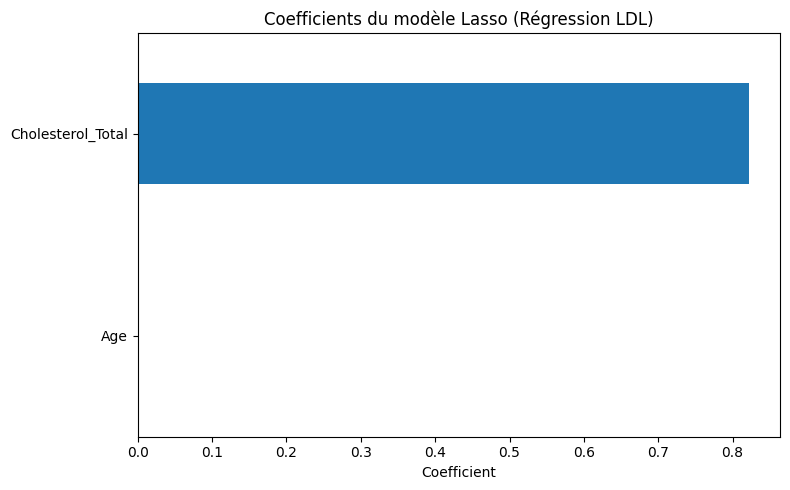

In [46]:
# Re-estimation avec le meilleur alpha pour accéder aux coefs
best_alpha_lasso_reg = lasso_reg.best_params_["alpha"]
lasso_reg_final = Lasso(alpha=best_alpha_lasso_reg, max_iter=5000)
lasso_reg_final.fit(Xr_reg_train, yr_reg_train)

coef_reg = pd.Series(lasso_reg_final.coef_, index=X_reg_train.columns)
print("Lasso conserve", sum(coef_reg != 0), "variables")
print("Variables conservées :", list(coef_reg[coef_reg != 0].index))

coef_reg_nonzero = coef_reg[coef_reg != 0].sort_values()
plt.figure(figsize=(8,5))
coef_reg_nonzero.plot(kind="barh")
plt.title("Coefficients du modèle Lasso (Régression LDL)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

Le résultat est frappant : le Lasso n'utilise que 2 variables sur 19. `Cholesterol_Total` domine avec de loin le coefficient le plus élevé, ce qui est attendu puisque le cholestérol total est par construction la somme du LDL, du HDL et des VLDL. `Age` apporte une contribution positive mais bien plus faible. Ce phénomène de dominance d'une seule variable est cohérent avec les résultats obtenus en R et sera analysé dans le cadre du data leakage en section 4.3.


### 4.1.4 Comparaison modèles linéaires (régression)

In [47]:
# Tableau récapitulatif
reg_lin_models = {
    "Linéaire complet": (pred_reg_full, r2_test_full, rmse_test_full),
    "Lasso": (pred_lasso_reg, r2_lasso, rmse_lasso),
    "Ridge": (pred_ridge_reg, r2_ridge, rmse_ridge),
    "Elastic Net": (pred_enet_reg, r2_enet, rmse_enet),
}

res_lin_reg = []
for nom, (pred, r2, rmse) in reg_lin_models.items():
    mae = mean_absolute_error(yr_reg_test, pred) * std_ldl
    res_lin_reg.append({"Modele": nom, "RMSE": round(rmse, 4),
                        "MAE": round(mae, 4), "R2": round(r2, 4)})

df_lin_reg = pd.DataFrame(res_lin_reg).sort_values("RMSE")
print(df_lin_reg.to_string(index=False))

          Modele    RMSE    MAE     R2
     Elastic Net 10.0690 8.0586 0.6648
           Lasso 10.0691 8.0588 0.6648
           Ridge 10.0817 8.0671 0.6639
Linéaire complet 10.0847 8.0683 0.6637


## 4.2 Régression par SVM : SVR pour Cholesterol_LDL

On teste 4 noyaux (linéaire, RBF, polynomial, sigmoïde) et on sélectionne le meilleur selon le RMSE test.

In [48]:
# Sous-échantillon pour accélérer
np.random.seed(111)
idx_small_reg = np.random.choice(len(Xr_reg_train), 5000, replace=False)
Xr_reg_train_small = Xr_reg_train[idx_small_reg]
yr_reg_train_small = yr_reg_train.iloc[idx_small_reg].values

**SVR : Noyau linéaire**

In [49]:
param_svr_lin = [{"C": [0.5, 1, 2]}]
svr_lin = GridSearchCV(SVR(kernel="linear"), param_svr_lin, cv=5, n_jobs=-1,
                       scoring="neg_mean_squared_error")
svr_lin.fit(Xr_reg_train_small, yr_reg_train_small)
print("SVR Linéaire - meilleur C:", svr_lin.best_params_["C"])

pred_svr_lin = svr_lin.predict(Xr_reg_test)
rmse_svr_lin = np.sqrt(mean_squared_error(yr_reg_test, pred_svr_lin)) * std_ldl
r2_svr_lin = r2_score(yr_reg_test, pred_svr_lin)
print(f"RMSE : {rmse_svr_lin:.4f} mg/dL | R² : {r2_svr_lin:.4f}")

SVR Linéaire - meilleur C: 0.5
RMSE : 10.0901 mg/dL | R² : 0.6634


**SVR : Noyau RBF (gaussien)**

In [50]:
param_svr_rbf = [{"C": [1, 2, 4], "gamma": [0.02, 0.04, 0.06]}]
svr_rbf = GridSearchCV(SVR(kernel="rbf"), param_svr_rbf, cv=5, n_jobs=-1,
                       scoring="neg_mean_squared_error")
svr_rbf.fit(Xr_reg_train_small, yr_reg_train_small)
print("SVR RBF - meilleurs params:", svr_rbf.best_params_)

pred_svr_rbf = svr_rbf.predict(Xr_reg_test)
rmse_svr_rbf = np.sqrt(mean_squared_error(yr_reg_test, pred_svr_rbf)) * std_ldl
r2_svr_rbf = r2_score(yr_reg_test, pred_svr_rbf)
print(f"RMSE : {rmse_svr_rbf:.4f} mg/dL | R² : {r2_svr_rbf:.4f}")

SVR RBF - meilleurs params: {'C': 1, 'gamma': 0.02}
RMSE : 10.3179 mg/dL | R² : 0.6480


**SVR : Noyau polynomial**

In [51]:
param_svr_poly = [{"C": [1, 2, 3], "degree": [2, 3], "gamma": [0.02, 0.04]}]
svr_poly = GridSearchCV(SVR(kernel="poly"), param_svr_poly, cv=5, n_jobs=-1,
                        scoring="neg_mean_squared_error")
svr_poly.fit(Xr_reg_train_small, yr_reg_train_small)
print("SVR Polynomial - meilleurs params:", svr_poly.best_params_)

pred_svr_poly = svr_poly.predict(Xr_reg_test)
rmse_svr_poly = np.sqrt(mean_squared_error(yr_reg_test, pred_svr_poly)) * std_ldl
r2_svr_poly = r2_score(yr_reg_test, pred_svr_poly)
print(f"RMSE : {rmse_svr_poly:.4f} mg/dL | R² : {r2_svr_poly:.4f}")

SVR Polynomial - meilleurs params: {'C': 3, 'degree': 3, 'gamma': 0.02}
RMSE : 10.8806 mg/dL | R² : 0.6086


**SVR : Noyau sigmoïde**

In [52]:
param_svr_sig = [{"C": [1, 2, 4], "gamma": [0.02, 0.04, 0.06]}]
svr_sig = GridSearchCV(SVR(kernel="sigmoid"), param_svr_sig, cv=5, n_jobs=-1,
                       scoring="neg_mean_squared_error")
svr_sig.fit(Xr_reg_train_small, yr_reg_train_small)
print("SVR Sigmoïde — meilleurs params:", svr_sig.best_params_)

pred_svr_sig = svr_sig.predict(Xr_reg_test)
rmse_svr_sig = np.sqrt(mean_squared_error(yr_reg_test, pred_svr_sig)) * std_ldl
r2_svr_sig = r2_score(yr_reg_test, pred_svr_sig)
print(f"RMSE : {rmse_svr_sig:.4f} mg/dL | R² : {r2_svr_sig:.4f}")

SVR Sigmoïde — meilleurs params: {'C': 1, 'gamma': 0.02}
RMSE : 13.2458 mg/dL | R² : 0.4199


In [53]:
# Comparaison des 4 noyaux SVR
svr_results = [
    {"Noyau": "Linéaire", "RMSE": rmse_svr_lin, "R2": r2_svr_lin},
    {"Noyau": "RBF",      "RMSE": rmse_svr_rbf, "R2": r2_svr_rbf},
    {"Noyau": "Polynomial","RMSE": rmse_svr_poly,"R2": r2_svr_poly},
    {"Noyau": "Sigmoïde", "RMSE": rmse_svr_sig, "R2": r2_svr_sig},
]
df_svr = pd.DataFrame(svr_results).sort_values("RMSE")
print(df_svr.round(4).to_string(index=False))
print("\nNoyau optimal :", df_svr.iloc[0]["Noyau"])

     Noyau    RMSE     R2
  Linéaire 10.0901 0.6634
       RBF 10.3179 0.6480
Polynomial 10.8806 0.6086
  Sigmoïde 13.2458 0.4199

Noyau optimal : Linéaire


**Interprétation des modèles :**

L’évaluation des différents noyaux du SVR montre que le noyau linéaire obtient les meilleures performances globales, avec un RMSE de 10,09 et un coefficient R² de 0,6634. Cela signifie que le modèle explique environ 66,3 % de la variabilité de la variable cible, tout en présentant l’erreur de prédiction moyenne la plus faible parmi les modèles testés.

- Le noyau RBF présente des performances proches (RMSE = 10,32 ; R²=0,6480), mais l’introduction d’une relation non linéaire n’apporte pas d’amélioration significative.
- Le noyau polynomial obtient des résultats plus faibles (RMSE = 10,88 ; R²=0,6086), ce qui peut indiquer une complexité inutile par rapport à la structure réelle des données.
- Le noyau sigmoïde est nettement moins performant (RMSE = 13,25 ; R²=0,4199), avec une erreur plus importante et une capacité explicative réduite.
  
Cela confirme que la relation entre Cholesterol_Total et Cholesterol_LDL est essentiellement linéaire. On obtient encore une fois la même conclusion qu'en R.

**Entraînement final du SVR sur tout le train avec le noyau optimal**

In [54]:
best_C_svr = svr_lin.best_params_["C"]

# Réentraînement sur TOUT le jeu d'entraînement (normalisé)
svr_final = SVR(kernel="linear", C=best_C_svr)
svr_final.fit(Xr_reg_train, yr_reg_train)

# Prédictions sur test
pred_svr_final = svr_final.predict(Xr_reg_test)


rmse_svr_final = np.sqrt(mean_squared_error(yr_reg_test, pred_svr_final)) * std_ldl
r2_svr_final = r2_score(yr_reg_test, pred_svr_final)

print("=== SVR Linéaire final (entraîné sur tout le train) ===")
print(f"Meilleur C : {best_C_svr}")
print(f"RMSE   : {rmse_svr_final:.4f} mg/dL")
print(f"R²     : {r2_svr_final:.4f}")

=== SVR Linéaire final (entraîné sur tout le train) ===
Meilleur C : 0.5
RMSE   : 10.0846 mg/dL
R²     : 0.6637


Le réentraînement du SVR linéaire sur l'intégralité du jeu d'entraînement (vs le sous-échantillon de 5 000 observations utilisé lors du grid search) donne un RMSE de 10,08 mg/dL et un R² de 0,664, soit des performances quasi identiques à celles obtenues avec le sous-échantillon. Cela confirme que la réduction des données pour accélérer l'optimisation ne biaise pas la sélection du noyau. Par rapport aux modèles linéaires (RMSE ≈ 10,07 à 10,08 mg/dL), le SVR linéaire est donc au même niveau, ce qui est attendu : les deux méthodes minimisent un critère linéaire sur les mêmes données.

## 4.3 Régression par arbre binaire (CART)

On optimise la profondeur par validation croisée. On compare 3 versions : avec `Cholesterol_Total`, sans `Cholesterol_Total` et sans `Cholesterol_Total` + `Cholesterol_HDL` pour étudier l'effet du data leakage.

### 4.3.1 Arbre complet (avec Cholesterol_Total)

In [55]:
param = [{"max_depth": list(range(2, 20))}]
tree_reg = GridSearchCV(DecisionTreeRegressor(random_state=111),
                        param, cv=10, n_jobs=-1,
                        scoring="neg_mean_squared_error")
tree_reg.fit(Xr_reg_train, yr_reg_train)
print("Arbre régression — profondeur optimale:", tree_reg.best_params_["max_depth"])

best_depth_tree_reg_CT = tree_reg.best_params_["max_depth"]  

pred_tree_reg = tree_reg.predict(Xr_reg_test)
rmse_tree_reg = np.sqrt(mean_squared_error(yr_reg_test, pred_tree_reg)) * std_ldl
r2_tree_reg = r2_score(yr_reg_test, pred_tree_reg)
mae_tree_reg = mean_absolute_error(yr_reg_test, pred_tree_reg) * std_ldl
print(f"RMSE : {rmse_tree_reg:.4f} | MAE : {mae_tree_reg:.4f} | R² : {r2_tree_reg:.4f}")


Arbre régression — profondeur optimale: 5
RMSE : 10.1719 | MAE : 8.1456 | R² : 0.6579


L'arbre de régression (profondeur optimale = 5) obtient un R² de 0,658 et une RMSE de 10,17 mg/dL, légèrement inférieur aux modèles linéaires. Avec Cholesterol_Total dans les features, l'arbre capte la relation principale mais est moins précis que la régression linéaire sur les zones intermédiaires. À noter que sklearn contrôle la complexité via max_depth directement, tandis que rpart en R élague par validation croisée sur le paramètre cp, ce qui peut donner des arbres de structure différente pour des performances similaires.

### 4.3.2 Arbre sans Cholesterol_Total (data leakage)

In [56]:
# Colonnes à exclure - Cholesterol_Total n'a pas de dummy donc c'est direct
# On cherche la colonne exacte dans X_reg
print("Colonnes Cholesterol :", [c for c in X_reg.columns if "Cholesterol" in c])

Colonnes Cholesterol : ['Cholesterol_Total', 'Cholesterol_HDL']


In [57]:
# Construction du jeu sans Cholesterol_Total
cols_sans_CT = [c for c in X_reg.columns if c != "Cholesterol_Total"]
X_reg_v2 = X_reg[cols_sans_CT]

X_reg_train_v2, X_reg_test_v2, y_reg_train_v2, y_reg_test_v2 = train_test_split(
    X_reg_v2, y_reg, test_size=0.2, random_state=111)

scaler_v2 = StandardScaler()
scaler_v2.fit(X_reg_train_v2)
Xr_reg_train_v2 = scaler_v2.transform(X_reg_train_v2)
Xr_reg_test_v2 = scaler_v2.transform(X_reg_test_v2)

yr_reg_train_v2 = (y_reg_train_v2 - mean_ldl) / std_ldl
yr_reg_test_v2 = (y_reg_test_v2 - mean_ldl) / std_ldl

# Arbre sans Cholesterol_Total
param = [{"max_depth": list(range(2, 20))}]
tree_reg_v2 = GridSearchCV(DecisionTreeRegressor(random_state=111),
                            param, cv=10, n_jobs=-1,
                            scoring="neg_mean_squared_error")
tree_reg_v2.fit(Xr_reg_train_v2, yr_reg_train_v2)
print("Arbre sans CT — profondeur:", tree_reg_v2.best_params_["max_depth"])

pred_tree_reg_v2 = tree_reg_v2.predict(Xr_reg_test_v2)
rmse_tree_v2 = np.sqrt(mean_squared_error(yr_reg_test_v2, pred_tree_reg_v2)) * std_ldl
r2_tree_v2 = r2_score(yr_reg_test_v2, pred_tree_reg_v2)
mae_tree_v2 = mean_absolute_error(yr_reg_test_v2, pred_tree_reg_v2) * std_ldl
print(f"RMSE : {rmse_tree_v2:.4f} | MAE : {mae_tree_v2:.4f} | R² : {r2_tree_v2:.4f}")

Arbre sans CT — profondeur: 4
RMSE : 16.1428 | MAE : 12.9682 | R² : 0.1384


Sans Cholesterol_Total, le R² s'effondre à 0,138 et la RMSE grimpe à 16,14 mg/dL. Ce résultat met en évidence l'effet de data leakage : Cholesterol_Total contient directement Cholesterol_LDL par construction biologique (CT = LDL + HDL + VLDL/5), ce qui gonfle artificiellement les performances de tous les modèles qui l'incluent. Sans elle, les variables restantes (âge, IMC, pression artérielle) n'expliquent que **14 % de la variance du LDL.**

### 4.3.3 Importance des variables

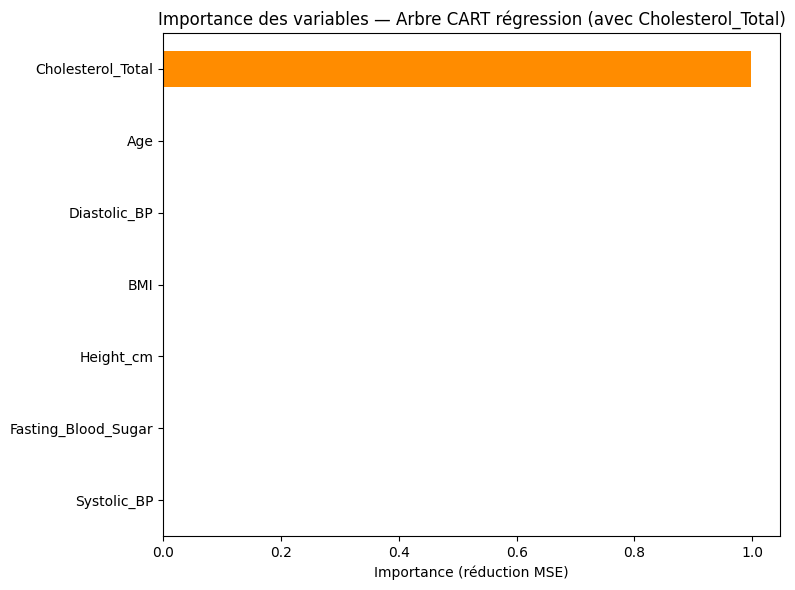

In [58]:
# Modèle final arbre (avec CT) pour l'importance
tree_reg_final = DecisionTreeRegressor(max_depth=best_depth_tree_reg_CT, random_state=111)
tree_reg_final.fit(Xr_reg_train, yr_reg_train)

imp_tree_reg = pd.Series(tree_reg_final.feature_importances_, index=X_reg_train.columns)
imp_tree_reg = imp_tree_reg[imp_tree_reg > 0].sort_values()

plt.figure(figsize=(8,6))
imp_tree_reg.plot(kind="barh", color="darkorange")
plt.title("Importance des variables — Arbre CART régression (avec Cholesterol_Total)")
plt.xlabel("Importance (réduction MSE)")
plt.tight_layout()
plt.show()

In [59]:
# Tableau comparatif CART régression
res_cart_reg = [
    {"Modele": "Arbre CART (avec CT)", "RMSE": round(rmse_tree_reg, 4),
     "MAE": round(mae_tree_reg, 4), "R2": round(r2_tree_reg, 4)},
    {"Modele": "Arbre CART (sans CT)", "RMSE": round(rmse_tree_v2, 4),
     "MAE": round(mae_tree_v2, 4), "R2": round(r2_tree_v2, 4)},
]
print(pd.DataFrame(res_cart_reg).to_string(index=False))

              Modele    RMSE     MAE     R2
Arbre CART (avec CT) 10.1719  8.1456 0.6579
Arbre CART (sans CT) 16.1428 12.9682 0.1384


## 4.4 Régression par forêt aléatoire

### 4.4.1 Convergence et optimisation de `max_features`

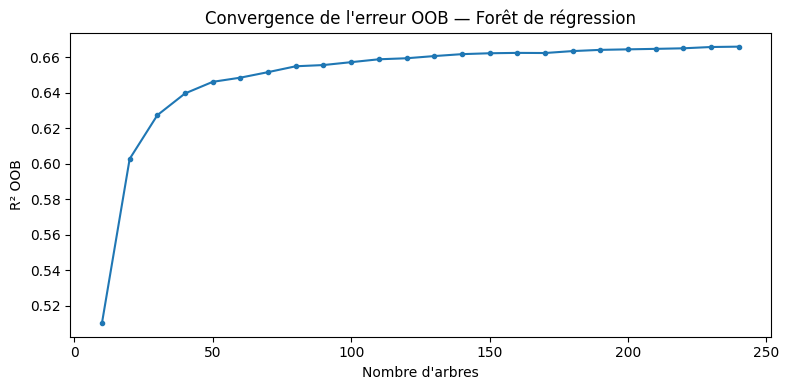

In [60]:
# Convergence OOB
oob_mse = []
n_trees_list = list(range(10, 250, 10))
for n in n_trees_list:
    rf_r = RandomForestRegressor(n_estimators=n, max_features="sqrt",
                                  oob_score=True, random_state=111)
    rf_r.fit(Xr_reg_train, yr_reg_train)
    oob_mse.append(rf_r.oob_score_)  # R² OOB

plt.figure(figsize=(8,4))
plt.plot(n_trees_list, oob_mse, marker="o", markersize=3)
plt.xlabel("Nombre d'arbres")
plt.ylabel("R² OOB")
plt.title("Convergence de l'erreur OOB — Forêt de régression")
plt.tight_layout()
plt.show()

In [61]:
# Optimisation max_features
param = [{"max_features": list(range(2, 12, 1))}]
rf_reg_opt = GridSearchCV(RandomForestRegressor(n_estimators=200, random_state=111),
                           param, cv=5, n_jobs=-1,
                           scoring="neg_mean_squared_error")
rf_reg_opt.fit(Xr_reg_train, yr_reg_train)
best_mf_reg = rf_reg_opt.best_params_["max_features"]
print("Forêt régression — meilleur max_features:", best_mf_reg)

Forêt régression — meilleur max_features: 10


La forêt de régression sélectionne max_features = 10, soit la moitié des 19 variables disponibles. Cette valeur est plus élevée que pour la classification (2 sur 20), ce qui s'explique par la forte dominance de Cholesterol_Total : tirer peu de variables risquerait trop souvent de l'exclure et d'appauvrir les arbres.

### 4.4.2 Modèle final et évaluation

R² OOB : 0.6782
RMSE test : 10.2606 mg/dL | MAE : 8.2347 | R² : 0.6519


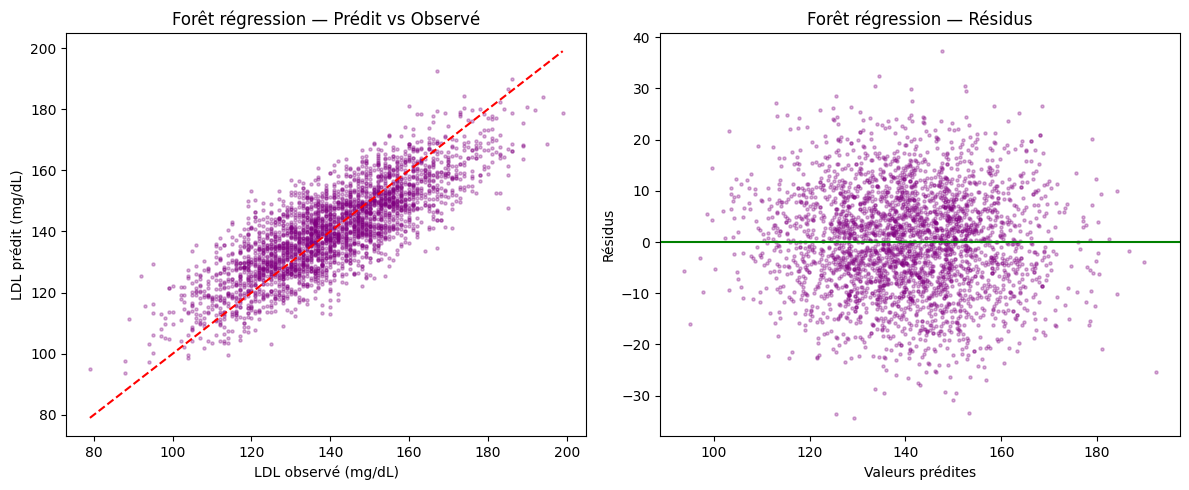

In [62]:
# Modèle final forêt régression
rf_reg_final = RandomForestRegressor(n_estimators=200, max_features=best_mf_reg,
                                      oob_score=True, random_state=111)
rf_reg_final.fit(Xr_reg_train, yr_reg_train)
print("R² OOB :", round(rf_reg_final.oob_score_, 4))

pred_rf_reg = rf_reg_final.predict(Xr_reg_test)
rmse_rf_reg = np.sqrt(mean_squared_error(yr_reg_test, pred_rf_reg)) * std_ldl
mae_rf_reg = mean_absolute_error(yr_reg_test, pred_rf_reg) * std_ldl
r2_rf_reg = r2_score(yr_reg_test, pred_rf_reg)
print(f"RMSE test : {rmse_rf_reg:.4f} mg/dL | MAE : {mae_rf_reg:.4f} | R² : {r2_rf_reg:.4f}")

# Graphe prédit vs observé
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
obs_real = yr_reg_test * std_ldl + mean_ldl
pred_real = pred_rf_reg * std_ldl + mean_ldl

ax1.scatter(obs_real, pred_real, alpha=0.3, color="purple", s=5)
ax1.plot([obs_real.min(), obs_real.max()], [obs_real.min(), obs_real.max()], 'r--')
ax1.set_xlabel("LDL observé (mg/dL)")
ax1.set_ylabel("LDL prédit (mg/dL)")
ax1.set_title("Forêt régression — Prédit vs Observé")

residus = (yr_reg_test - pred_rf_reg) * std_ldl
ax2.scatter(pred_real, residus, alpha=0.3, color="purple", s=5)
ax2.axhline(0, color="green")
ax2.set_xlabel("Valeurs prédites")
ax2.set_ylabel("Résidus")
ax2.set_title("Forêt régression — Résidus")
plt.tight_layout()
plt.show()

La forêt aléatoire (200 arbres, max_features = 10) obtient un R² OOB de 0,678 et un R² test de 0,653, légèrement inférieur aux modèles linéaires. Ce comportement est typique quand la relation est quasi linéaire : les méthodes par ensembles n'apportent pas de gain significatif et introduisent même une légère perte de précision par rapport à la régression linéaire.

### 4.4.3 Importance des variables

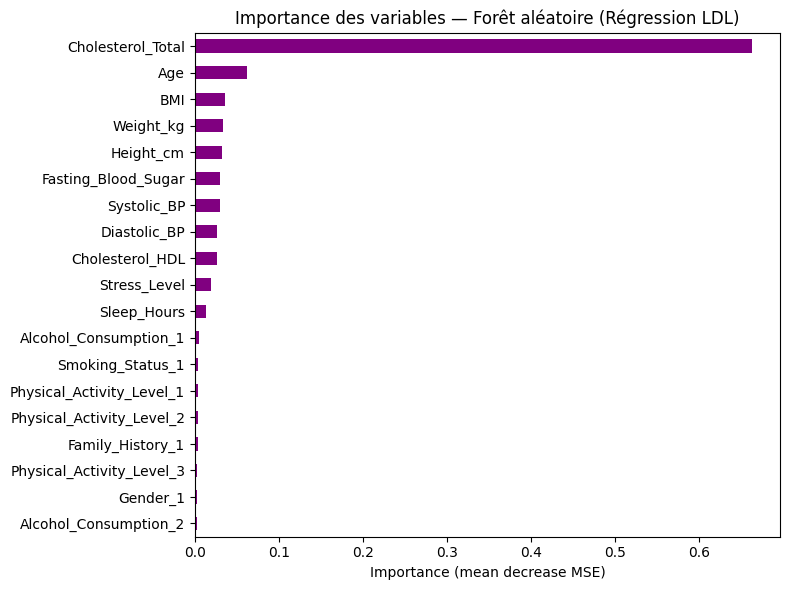

In [63]:
imp_rf_reg = pd.Series(rf_reg_final.feature_importances_, index=X_reg_train.columns)
imp_rf_reg = imp_rf_reg.sort_values()

plt.figure(figsize=(8,6))
imp_rf_reg.plot(kind="barh", color="purple")
plt.title("Importance des variables — Forêt aléatoire (Régression LDL)")
plt.xlabel("Importance (mean decrease MSE)")
plt.tight_layout()
plt.show()

Encore une fois, le Cholesterol_Total domine massivement l'importance des variables de la forêt de régression, accaparant la quasi-totalité de la réduction de MSE. Age et Cholesterol_HDL apparaissent en deuxième position mais avec une contribution bien plus faible. Ce résultat illustre à nouveau le phénomène de data leakage identifié en section 4.3.2 : toute méthode qui inclut Cholesterol_Total est fondamentalement guidée par cette seule variable, puisque par construction biologique LDL ≈ CT − HDL − VLDL/5. Cette importance est cohérente avec celle observée en R et avec les coefficients du Lasso (section 4.1.3).

## 4.5 Régression par Boosting

### 4.5.1 Estimation initiale

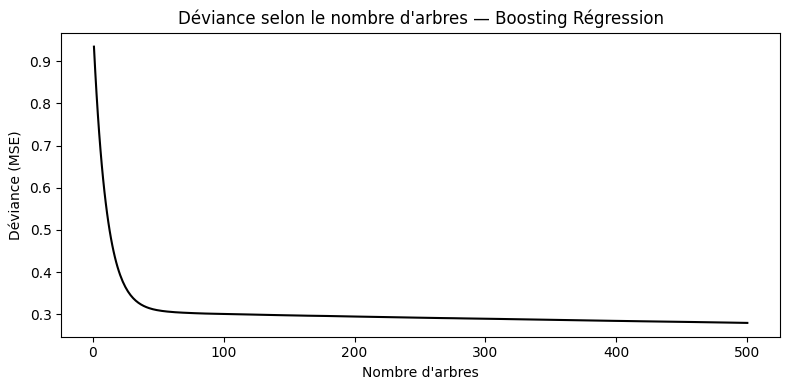

In [64]:
# Estimation initiale pour choisir le nombre d'arbres
boost_reg_init = GradientBoostingRegressor(n_estimators=500, max_depth=3,
                                             learning_rate=0.05, min_samples_leaf=10,
                                             random_state=111)
boost_reg_init.fit(Xr_reg_train, yr_reg_train)

train_scores_reg = boost_reg_init.train_score_
plt.figure(figsize=(8,4))
plt.plot(range(1, len(train_scores_reg)+1), train_scores_reg, color="black")
plt.xlabel("Nombre d'arbres")
plt.ylabel("Déviance (MSE)")
plt.title("Déviance selon le nombre d'arbres — Boosting Régression")
plt.tight_layout()
plt.show()

Comme pour la forêt aléatoire, Cholesterol_Total domine l'importance des variables du boosting de régression. Le classement des variables secondaires (Age, Cholesterol_HDL, Fasting_Blood_Sugar) est cohérent entre les deux méthodes, ce qui renforce la robustesse du résultat. Le boosting converge vers la même conclusion que les autres modèles : la prédiction du LDL est essentiellement un problème de régression linéaire dominé par le cholestérol total.

### 4.5.2 Optimisation des hyperparamètres

In [65]:
param_boost_reg = [{"max_depth": [1, 3, 5],
                    "learning_rate": [0.01, 0.05, 0.1]}]
boost_reg_cv = GridSearchCV(GradientBoostingRegressor(n_estimators=300, min_samples_leaf=10,
                                                        random_state=111),
                             param_boost_reg, cv=5, n_jobs=-1,
                             scoring="neg_mean_squared_error")
boost_reg_cv.fit(Xr_reg_train, yr_reg_train)
print("Boosting régression — meilleurs params:", boost_reg_cv.best_params_)

Boosting régression — meilleurs params: {'learning_rate': 0.05, 'max_depth': 1}


La configuration optimale retient une profondeur de 1 (arbres souches) avec un learning rate de 0,05. Des arbres aussi peu profonds correspondent à une stratégie d'agrégation de modèles quasi linéaires, ce qui est cohérent avec la nature linéaire dominante du problème.

### 4.5.3 Modèle final et évaluation

In [66]:
best_depth_br = boost_reg_cv.best_params_["max_depth"]
best_lr_br = boost_reg_cv.best_params_["learning_rate"]

boost_reg_final = GradientBoostingRegressor(n_estimators=300,
                                              max_depth=best_depth_br,
                                              learning_rate=best_lr_br,
                                              min_samples_leaf=10,
                                              random_state=111)
boost_reg_final.fit(Xr_reg_train, yr_reg_train)

pred_boost_reg = boost_reg_final.predict(Xr_reg_test)
rmse_boost_reg = np.sqrt(mean_squared_error(yr_reg_test, pred_boost_reg)) * std_ldl
mae_boost_reg = mean_absolute_error(yr_reg_test, pred_boost_reg) * std_ldl
r2_boost_reg = r2_score(yr_reg_test, pred_boost_reg)
print(f"RMSE : {rmse_boost_reg:.4f} mg/dL | MAE : {mae_boost_reg:.4f} | R² : {r2_boost_reg:.4f}")

RMSE : 10.0900 mg/dL | MAE : 8.0844 | R² : 0.6634


Le boosting (300 arbres souches, lr = 0,05) atteint une RMSE de 10,09 mg/dL et un R² de 0,663, performance comparable aux modèles linéaires pénalisés. C'est le deuxième meilleur résultat derrière l'Elastic Net (RMSE = 10,069), confirmant que pour ce problème à dominante linéaire, le boosting converge vers une solution proche de la régression.

### 4.5.4 Importance des variables

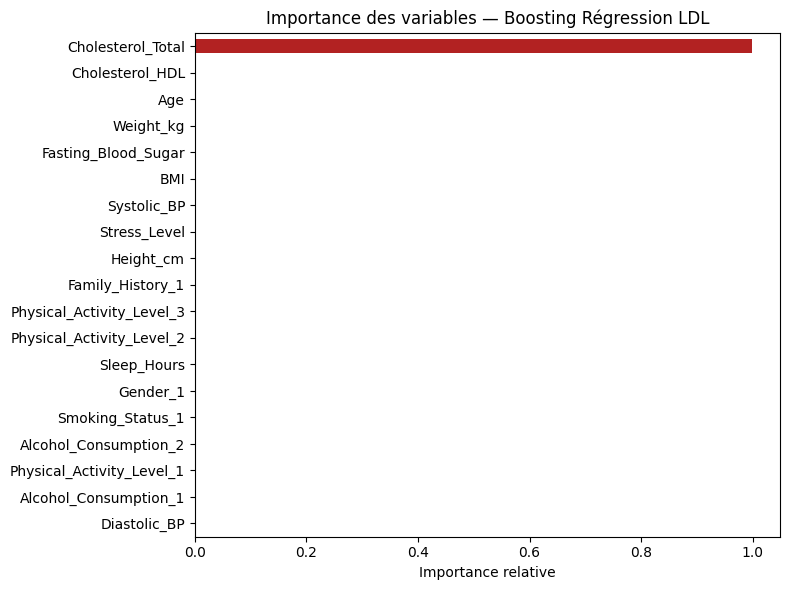

In [67]:
imp_boost_reg = pd.Series(boost_reg_final.feature_importances_, index=X_reg_train.columns)
imp_boost_reg = imp_boost_reg.sort_values()

plt.figure(figsize=(8,6))
imp_boost_reg.plot(kind="barh", color="firebrick")
plt.title("Importance des variables — Boosting Régression LDL")
plt.xlabel("Importance relative")
plt.tight_layout()
plt.show()

## 4.6 Régression par réseaux de neurones

Même logique que pour la classification, avec `MLPRegressor`. La différence principale est `activation` linéaire en sortie, ce qui est automatique avec `MLPRegressor` (équivalent de `linout=TRUE` en R).

### 4.6.1 Optimisation grossière

In [68]:
param_nnet_reg = [{"hidden_layer_sizes": [(2,),(5,),(8,)],
                   "alpha": [0.001, 0.01, 0.1, 1]}]
nnet_reg_cv1 = GridSearchCV(MLPRegressor(max_iter=200, random_state=101),
                             param_nnet_reg, cv=5, n_jobs=-1,
                             scoring="neg_mean_squared_error")
nnet_reg_cv1.fit(Xr_reg_train, yr_reg_train)
print("Réseau régression — meilleurs params:", nnet_reg_cv1.best_params_)
print("MSE CV :", round(-nnet_reg_cv1.best_score_, 4))

Réseau régression — meilleurs params: {'alpha': 1, 'hidden_layer_sizes': (2,)}
MSE CV : 0.3101


La première optimisation grossière identifie 2 neurones cachés avec une régularisation forte (alpha = 1). La MSE CV de 0,310 (en unités normalisées) correspond à une RMSE d'environ 10,0 mg/dL sur l'échelle originale.

### 4.6.2 Optimisation fine

In [69]:
param_nnet_reg2 = [{"hidden_layer_sizes": [(1,),(2,)],
                    "alpha": [0.005, 0.01, 0.05, 0.1]}]
nnet_reg_cv2 = GridSearchCV(MLPRegressor(max_iter=250, random_state=101),
                             param_nnet_reg2, cv=5, n_jobs=-1,
                             scoring="neg_mean_squared_error")
nnet_reg_cv2.fit(Xr_reg_train, yr_reg_train)
print("Optimisation fine — meilleurs params:", nnet_reg_cv2.best_params_)
print("MSE CV :", round(-nnet_reg_cv2.best_score_, 4))

Optimisation fine — meilleurs params: {'alpha': 0.005, 'hidden_layer_sizes': (1,)}
MSE CV : 0.3108


L'optimisation fine converge vers 1 neurone caché avec alpha = 0,005. Comme pour la classification, cette architecture minimale indique que la non-linéarité apportée par les neurones supplémentaires ne compense pas le risque de surapprentissage sur ce dataset.

### 4.6.3 Modèle final et évaluation

RMSE : 10.1045 mg/dL | MAE : 8.0834 | R² : 0.6624


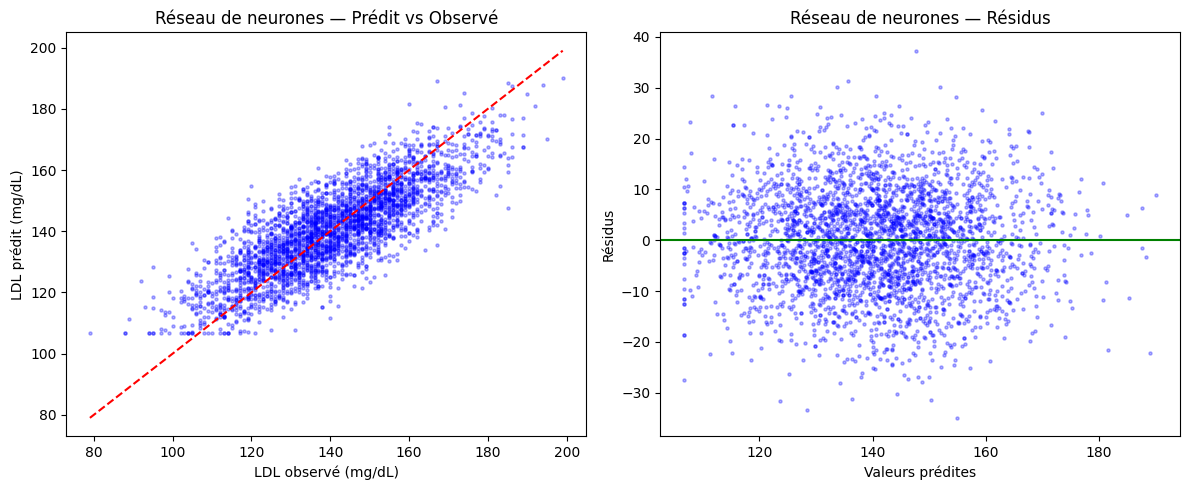

In [70]:
best_size_nnet_reg = nnet_reg_cv2.best_params_["hidden_layer_sizes"]
best_alpha_nnet_reg = nnet_reg_cv2.best_params_["alpha"]

nnet_reg_final = MLPRegressor(hidden_layer_sizes=best_size_nnet_reg,
                               alpha=best_alpha_nnet_reg,
                               max_iter=500, random_state=42)
nnet_reg_final.fit(Xr_reg_train, yr_reg_train)

pred_nnet_reg = nnet_reg_final.predict(Xr_reg_test)
rmse_nnet_reg = np.sqrt(mean_squared_error(yr_reg_test, pred_nnet_reg)) * std_ldl
mae_nnet_reg = mean_absolute_error(yr_reg_test, pred_nnet_reg) * std_ldl
r2_nnet_reg = r2_score(yr_reg_test, pred_nnet_reg)
print(f"RMSE : {rmse_nnet_reg:.4f} mg/dL | MAE : {mae_nnet_reg:.4f} | R² : {r2_nnet_reg:.4f}")

# Graphe prédit vs observé
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
obs_real = yr_reg_test * std_ldl + mean_ldl
pred_nnet_real = pred_nnet_reg * std_ldl + mean_ldl

ax1.scatter(obs_real, pred_nnet_real, alpha=0.3, color="blue", s=5)
ax1.plot([obs_real.min(), obs_real.max()], [obs_real.min(), obs_real.max()], 'r--')
ax1.set_xlabel("LDL observé (mg/dL)")
ax1.set_ylabel("LDL prédit (mg/dL)")
ax1.set_title("Réseau de neurones — Prédit vs Observé")

residus_nnet = (yr_reg_test - pred_nnet_reg) * std_ldl
ax2.scatter(pred_nnet_real, residus_nnet, alpha=0.3, color="blue", s=5)
ax2.axhline(0, color="green")
ax2.set_xlabel("Valeurs prédites")
ax2.set_ylabel("Résidus")
ax2.set_title("Réseau de neurones — Résidus")
plt.tight_layout()
plt.show()

Le réseau de neurones (1 neurone, alpha = 0,005) atteint une RMSE de 10,10 mg/dL et un R² de 0,662, résultats très proches des modèles linéaires. Ce résultat confirme une nouvelle fois que la relation modélisée est essentiellement linéaire.

## 4.7 Comparaison finale de tous les modèles de régression

In [71]:
# Tableau récapitulatif complet
all_reg_models = {
    "Linéaire complet": pred_reg_full,
    "Lasso": pred_lasso_reg,
    "Ridge": pred_ridge_reg,
    "Elastic Net": pred_enet_reg,
    "SVR Linéaire": pred_svr_lin,
    "SVR RBF": pred_svr_rbf,
    "Arbre CART": pred_tree_reg,
    "Forêt aléatoire": pred_rf_reg,
    "Boosting": pred_boost_reg,
    "Réseau de neurones": pred_nnet_reg,
}

res_all_reg = []
for nom, pred in all_reg_models.items():
    # récupère le bon y_test selon que c'est normalisé ou pas
    rmse = np.sqrt(mean_squared_error(yr_reg_test, pred)) * std_ldl
    mae = mean_absolute_error(yr_reg_test, pred) * std_ldl
    r2 = r2_score(yr_reg_test, pred)
    res_all_reg.append({"Modele": nom, "RMSE": round(rmse, 4),
                         "MAE": round(mae, 4), "R2": round(r2, 4)})

df_all_reg = pd.DataFrame(res_all_reg).sort_values("RMSE")
print(df_all_reg.to_string(index=False))

            Modele    RMSE    MAE     R2
       Elastic Net 10.0690 8.0586 0.6648
             Lasso 10.0691 8.0588 0.6648
             Ridge 10.0817 8.0671 0.6639
  Linéaire complet 10.0847 8.0683 0.6637
          Boosting 10.0900 8.0844 0.6634
      SVR Linéaire 10.0901 8.0664 0.6634
Réseau de neurones 10.1045 8.0834 0.6624
        Arbre CART 10.1719 8.1456 0.6579
   Forêt aléatoire 10.2606 8.2347 0.6519
           SVR RBF 10.3179 8.2336 0.6480


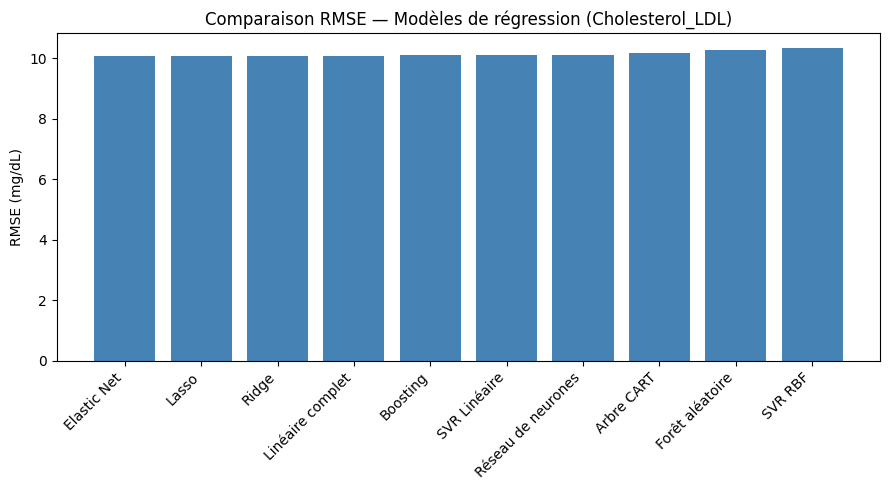

In [72]:
# Graphe comparatif RMSE
plt.figure(figsize=(9,5))
plt.bar(df_all_reg["Modele"], df_all_reg["RMSE"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE (mg/dL)")
plt.title("Comparaison RMSE — Modèles de régression (Cholesterol_LDL)")
plt.tight_layout()
plt.show()

**Conclusion de la partie régression :**

Tous les modèles testés se concentrent dans une plage de RMSE très étroite : entre 10,07 et 10,32 mg/dL (en excluant le SVR sigmoïde), avec un R² autour de 0,663 à 0,665 pour les meilleurs. Plusieurs constats s'imposent :

- L'Elastic Net et le Lasso sont les modèles les plus performants (RMSE = 10,069 mg/dL, R² = 0,665), mais l'avantage sur la régression linéaire complète est inférieur à 0,02 mg/dL — négligeable en pratique.
- Les modèles non linéaires (forêt, boosting) n'apportent aucun gain par rapport aux modèles linéaires, confirmant que la relation est essentiellement linéaire, dominée par Cholesterol_Total.
- La vraie difficulté de ce problème apparaît en section 4.3.2 : sans Cholesterol_Total, le R² s'effondre à 0,138, révélant que les variables médicales réellement disponibles en clinique (âge, IMC, pression artérielle...) n'expliquent que 14 % de la variabilité du LDL. Ce point est crucial pour l'interprétation médicale des résultats.

**Avec contrainte d'interprétabilité :** le Lasso est à privilégier car il ne sélectionne que 2 variables (Cholesterol_Total et Age) et ses coefficients sont directement interprétables.

**Sans contrainte :** l'Elastic Net (alpha = 0,01, l1_ratio = 0,9) ou la régression linéaire complète suffisent, les modèles plus complexes n'améliorant pas significativement les performances.
Ces résultats sont cohérents avec ceux obtenus en R.

## Conclusion générale

Les résultats Python confirment et complètent ceux obtenus en R.

**Classification (Heart_Disease_Risk) :**
Les performances sont proches entre tous les modèles (Accuracy ≈ 75 %, AUC ≈ 0,815). Les modèles linéaires (régression logistique, réseau de neurones à 1 neurone) dominent légèrement les méthodes non linéaires, ce qui indique une frontière de décision essentiellement linéaire. Les variables les plus importantes sont `Smoking_Status` et `Family_History`, résultat cohérent entre tous les modèles et avec l'analyse exploratoire en R.

**Régression (Cholesterol_LDL) :**
Tous les modèles atteignent un R² ≈ 0,665 grâce à la présence de Cholesterol_Total, variable redondante par construction biologique (data leakage). Sans elle, le R² chute à 0,138, ce qui révèle la faible prédictibilité intrinsèque du LDL à partir des variables cliniques disponibles. Le Lasso ne retient que `Cholesterol_Total` et `Age`, et les modèles non linéaires n'apportent aucun gain.

**Cohérence Python / R :**
Les deux notebooks convergent vers les mêmes conclusions qualitatives. Les légères différences numériques s'expliquent par des différences d'implémentation (ex. : max_depth vs cp pour les arbres, gbm vs GradientBoostingClassifier pour le boosting) et non par des erreurs. Les hyperparamètres optimaux sont systématiquement du même ordre de grandeur dans les deux langages.